# Tutorial for visualizing predicates

In [1]:
from commonroad.common.file_reader import CommonRoadFileReader

from crmonitor.common.world import World
from crmonitor.evaluation.evaluation import RuleEvaluator

from matplotlib import pyplot as plt
from commonroad.visualization.mp_renderer import MPRenderer

## Load scenario & plot

In [3]:
scenario_name = 'DEU_test_safe_distance'
scenario_path = f"../scenarios/test_interstate/{scenario_name}.xml"

scenario, planning_problem_set = CommonRoadFileReader(scenario_path).open(lanelet_assignment=True)
ego_vehicle = next(iter(scenario.dynamic_obstacles))

/home/sebastian/anaconda3/envs/commonroad-stl-monitor/lib/python3.7/site-packages/commonroad/scenario/scenario.py:397: UserWarning: Not a valid scenario ID: DEU_test_safe_distance
  warnings.warn('Not a valid scenario ID: ' + benchmark_id)


/home/sebastian/anaconda3/envs/commonroad-stl-monitor/lib/python3.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  


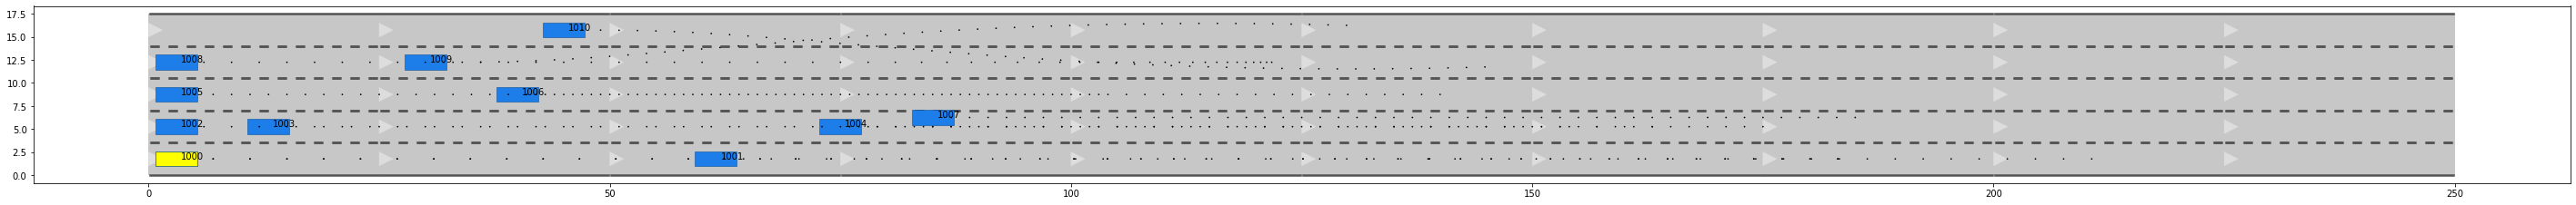

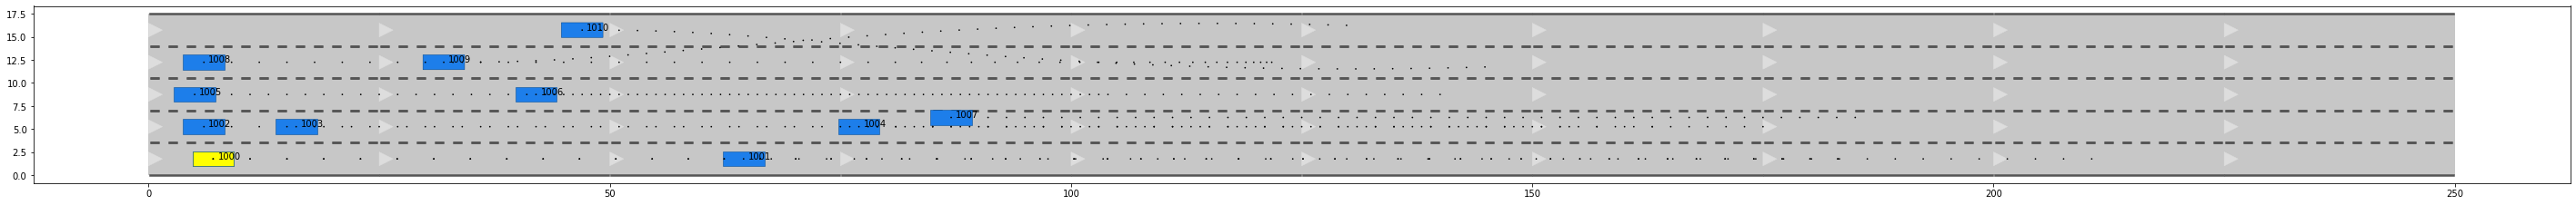

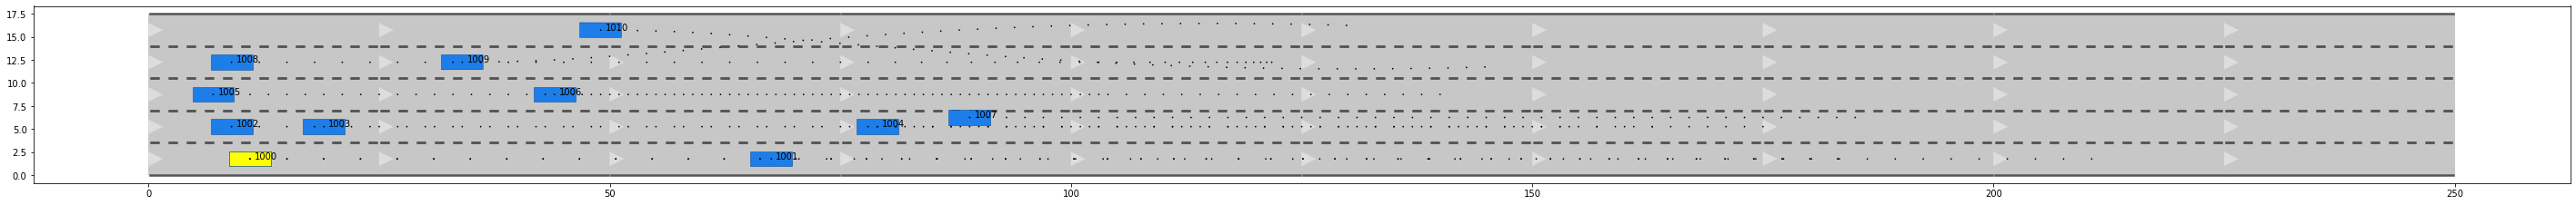

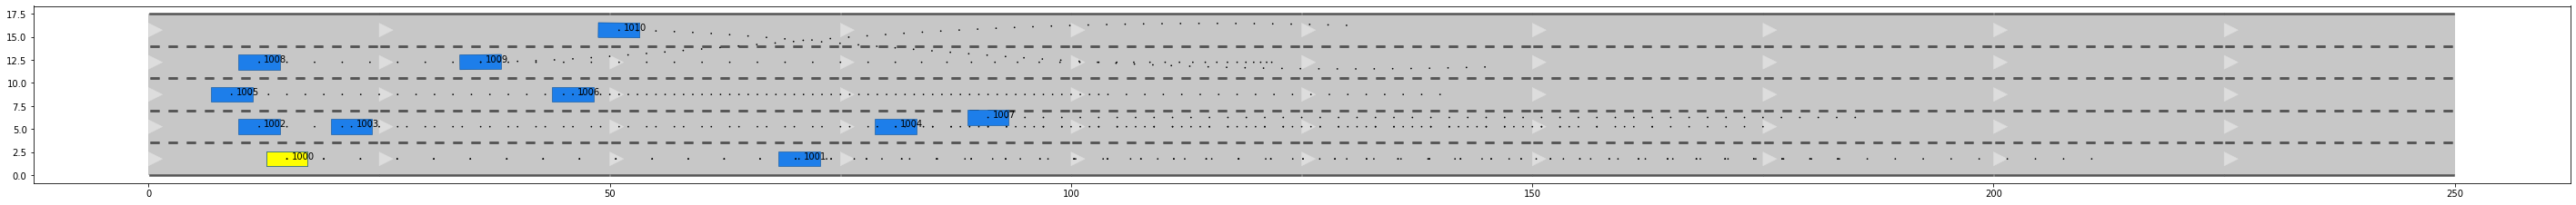

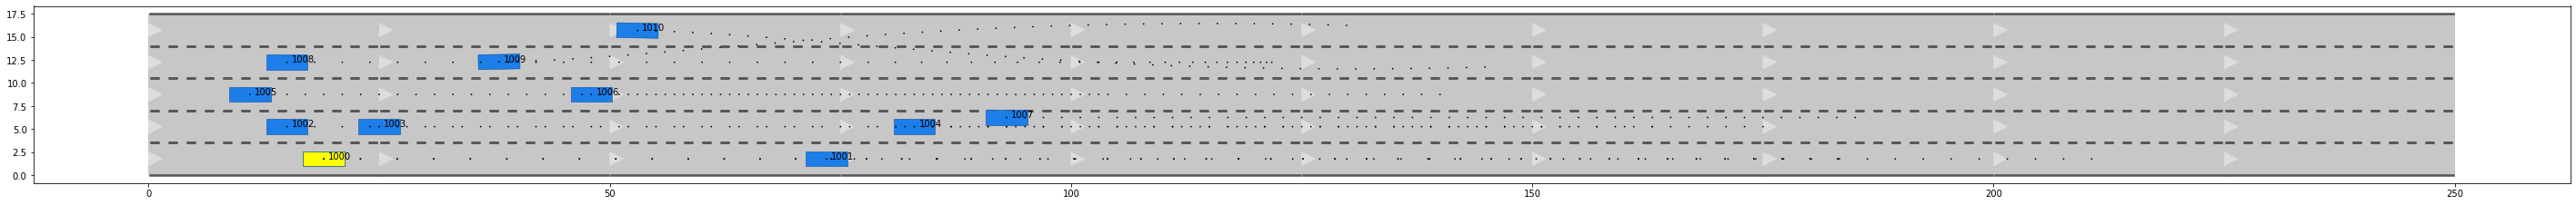

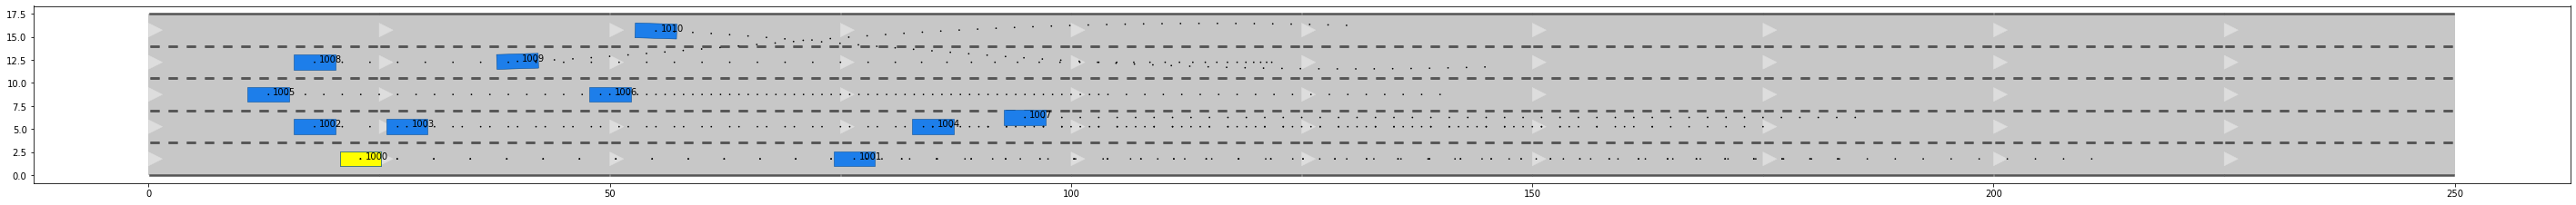

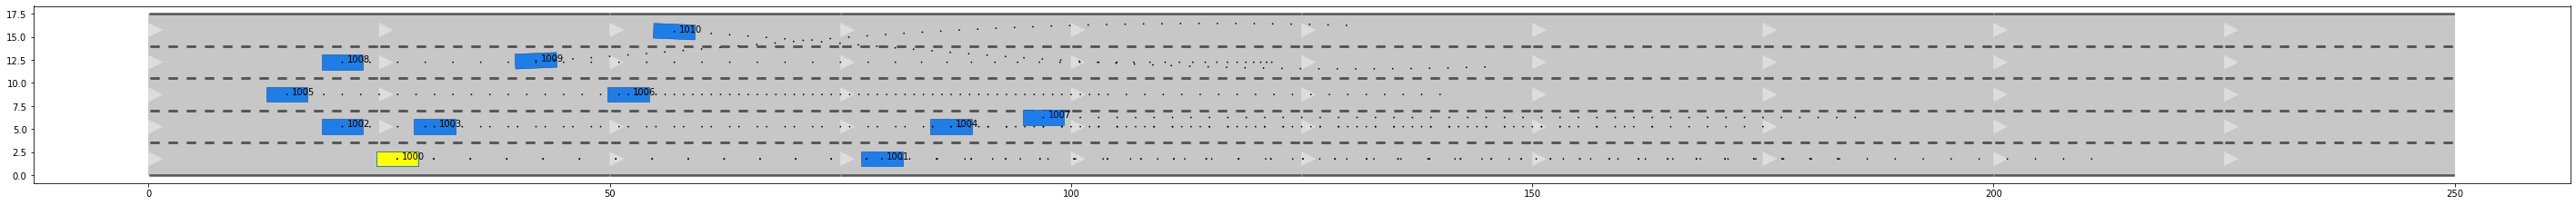

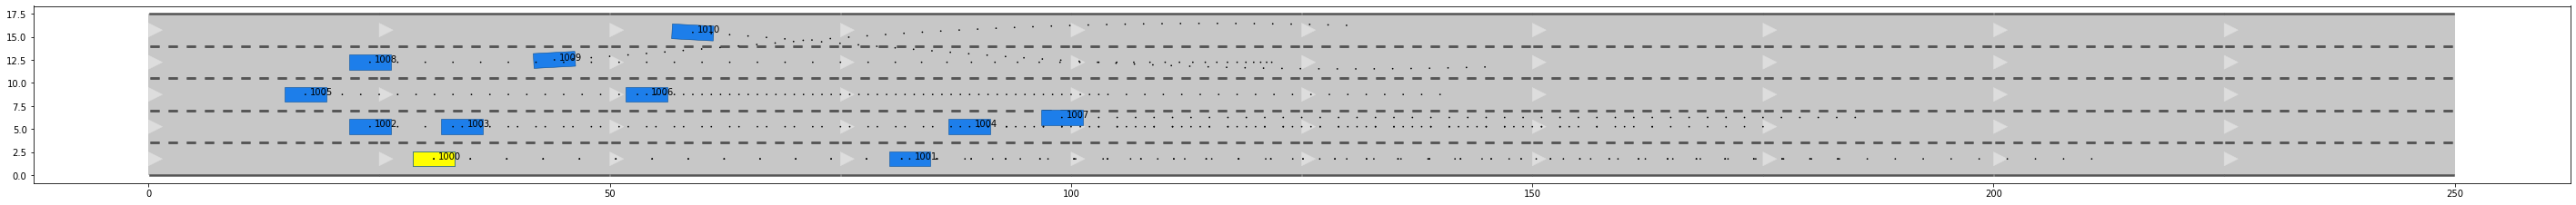

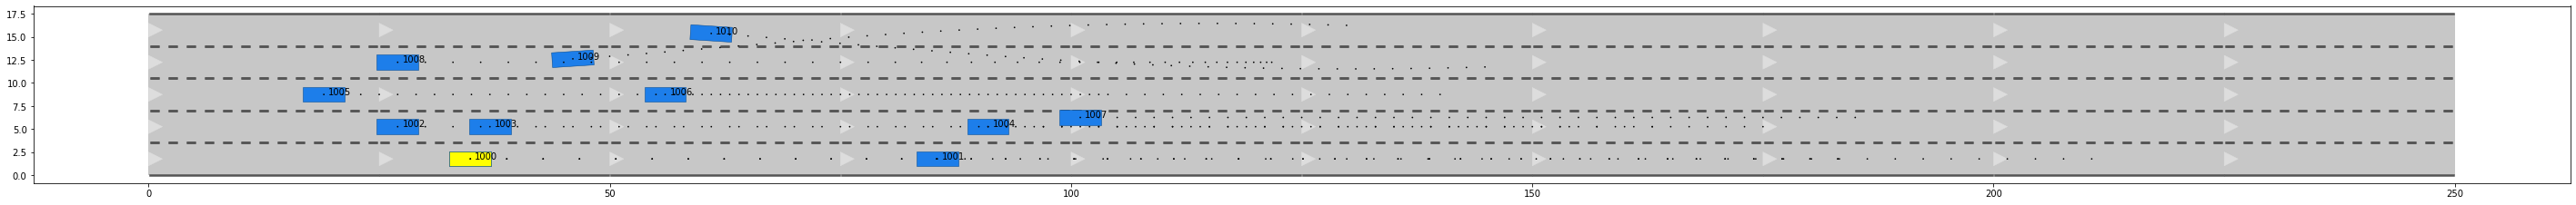

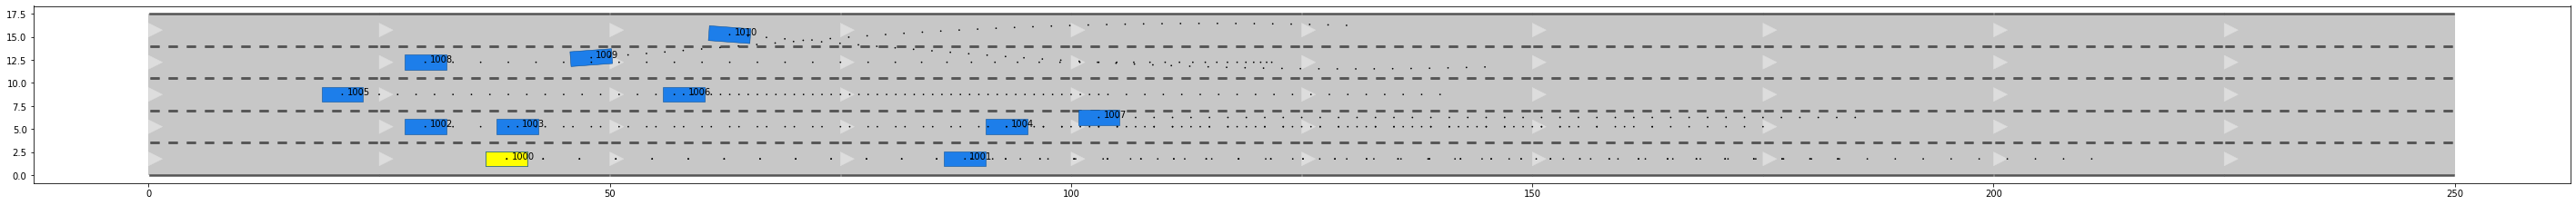

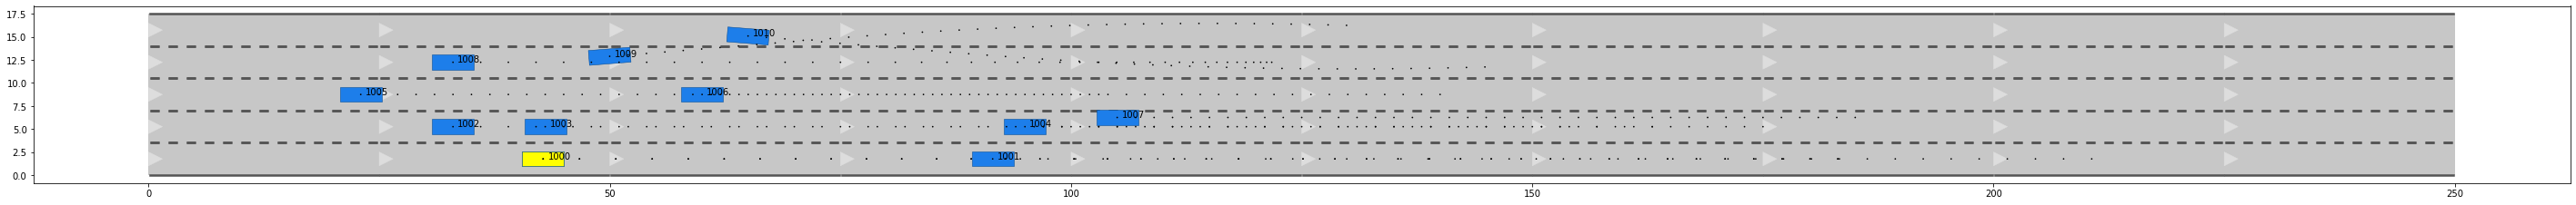

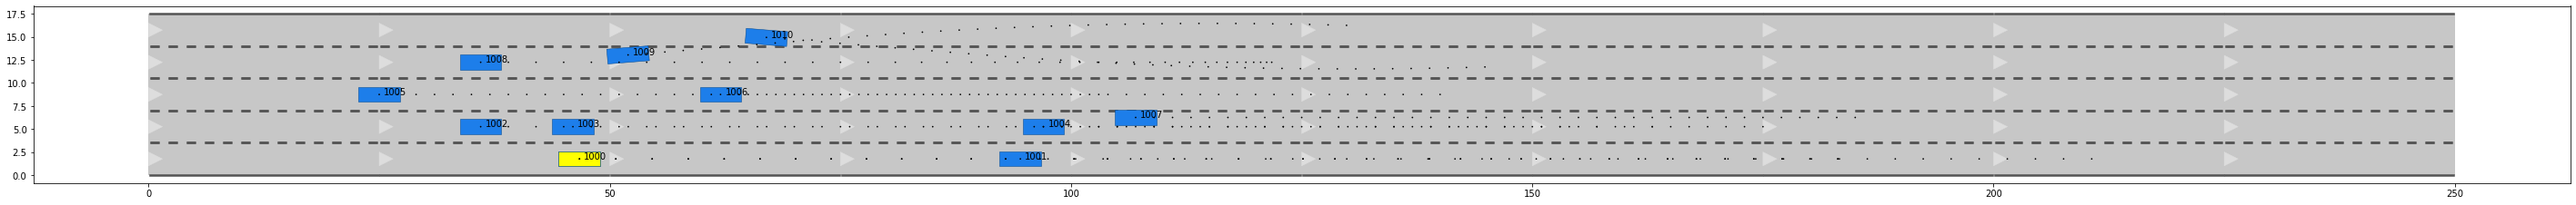

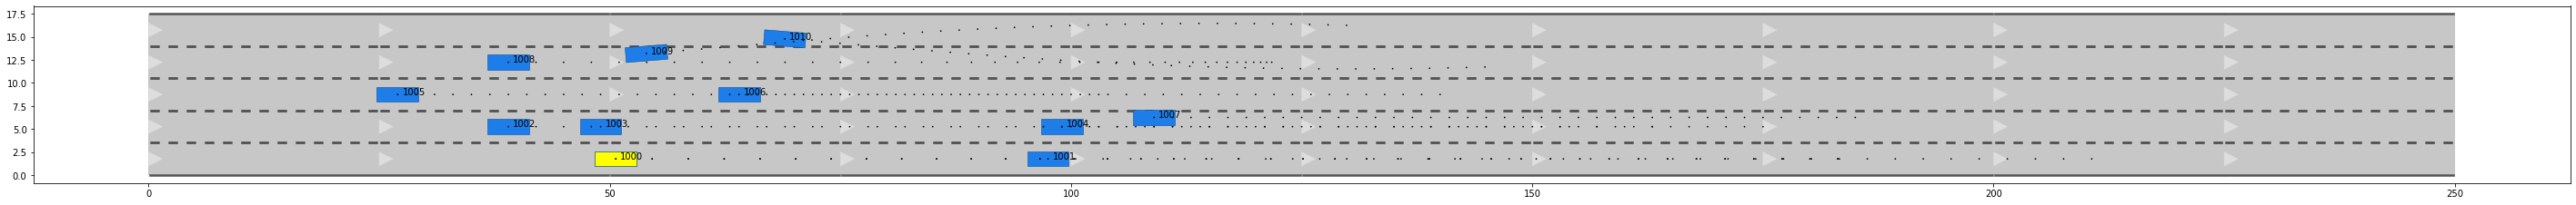

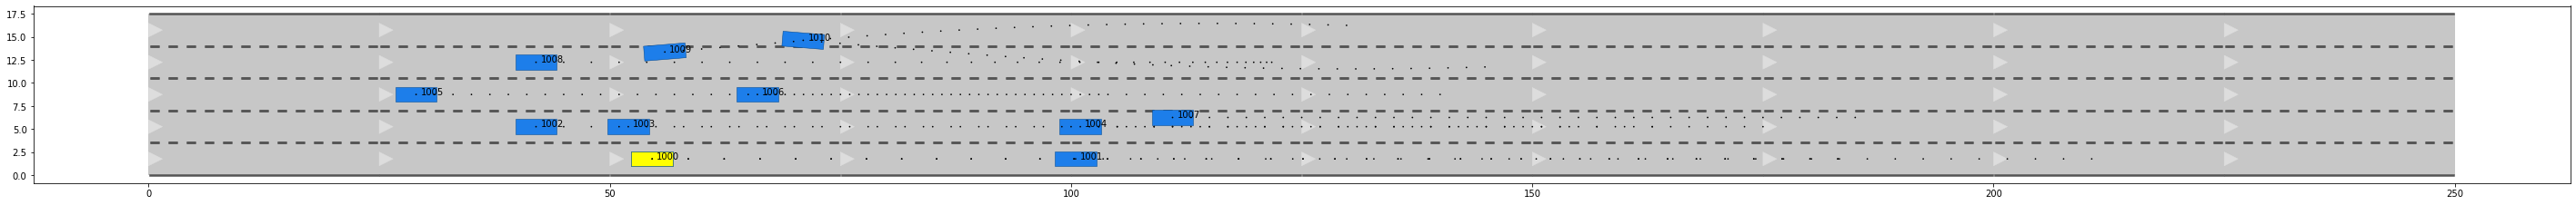

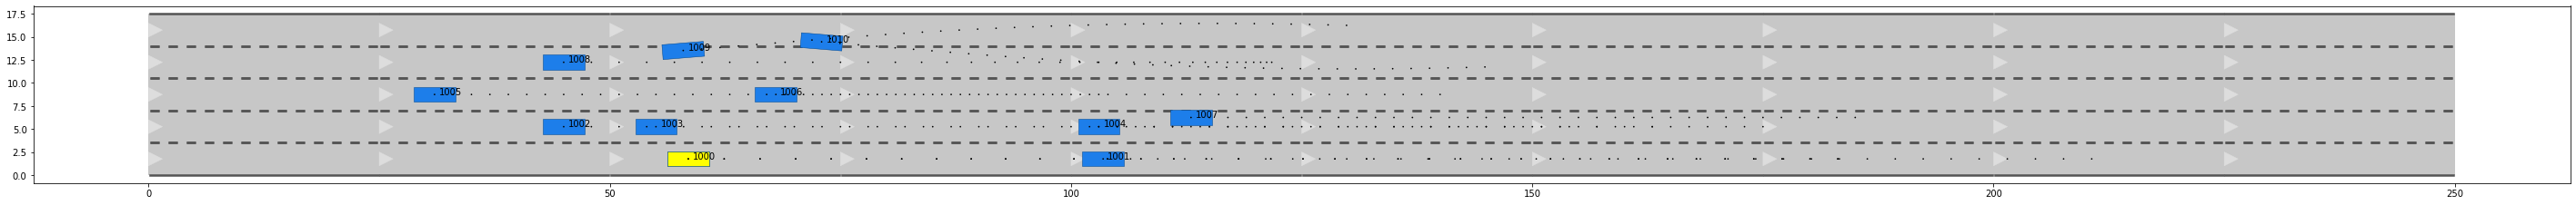

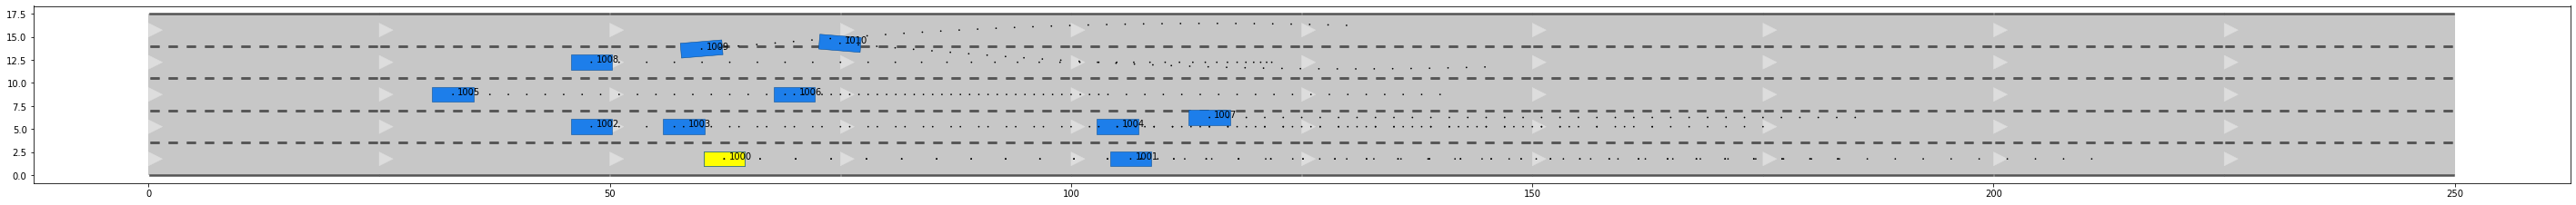

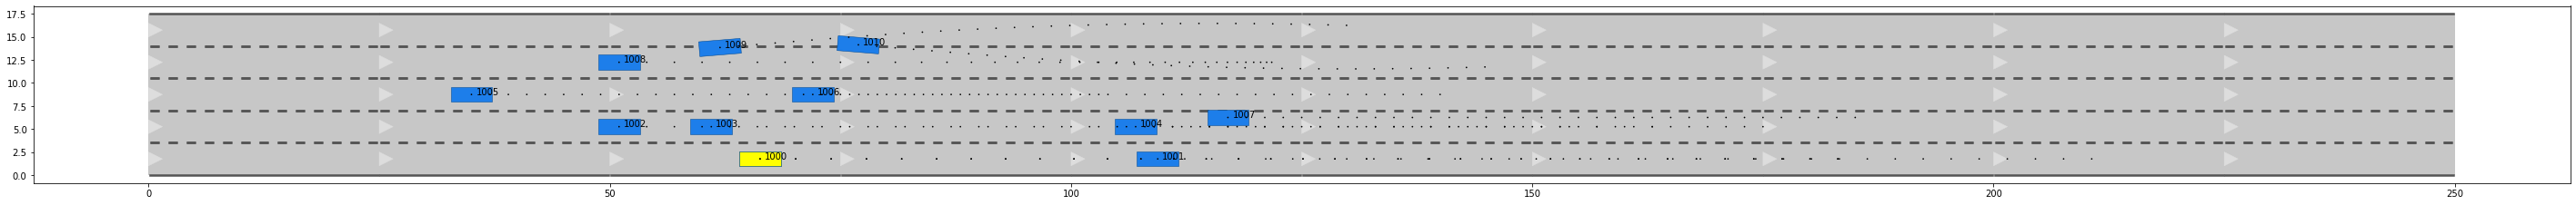

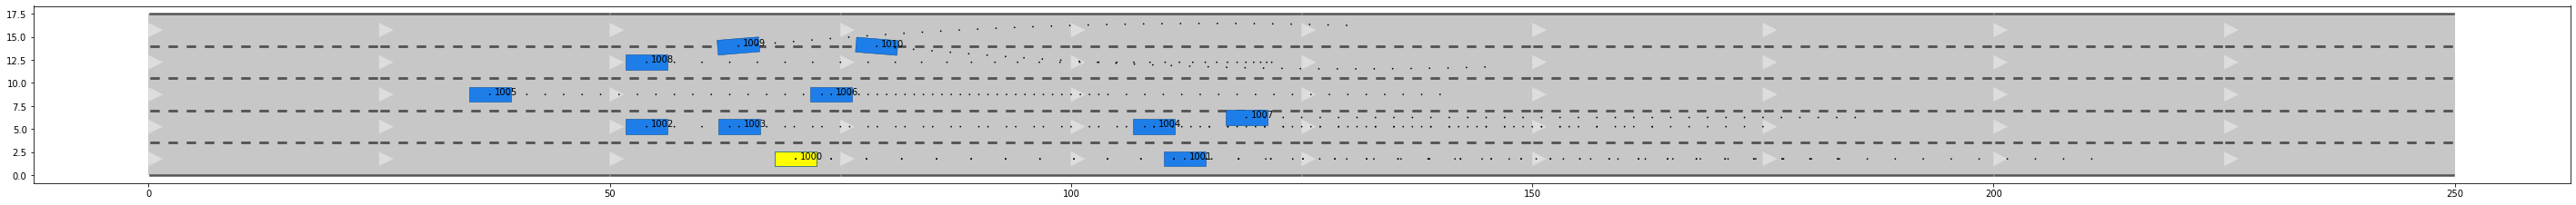

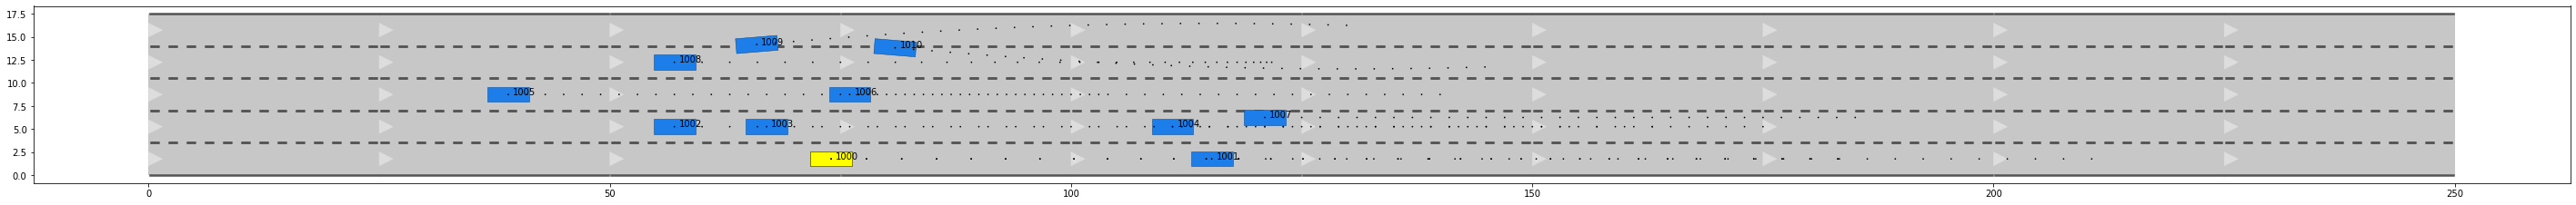

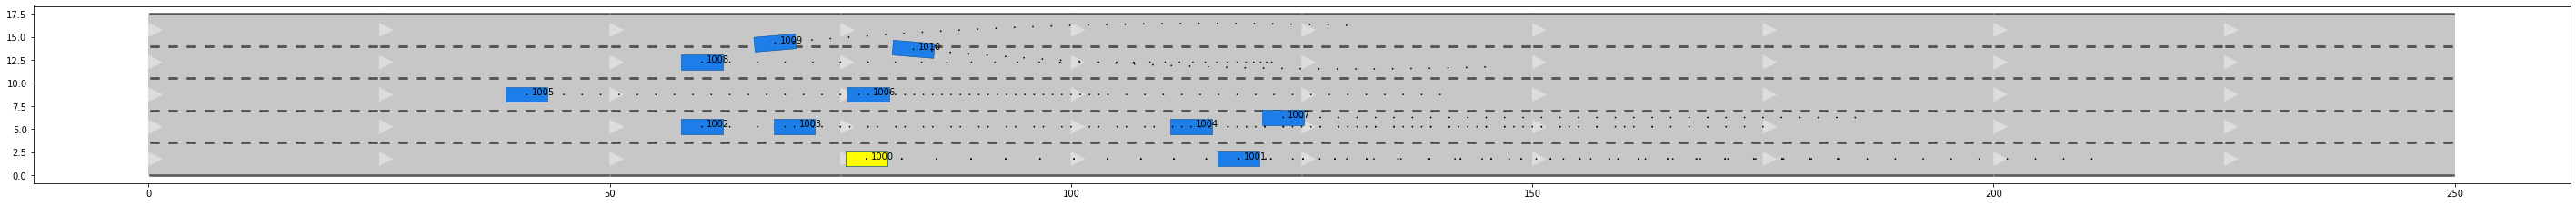

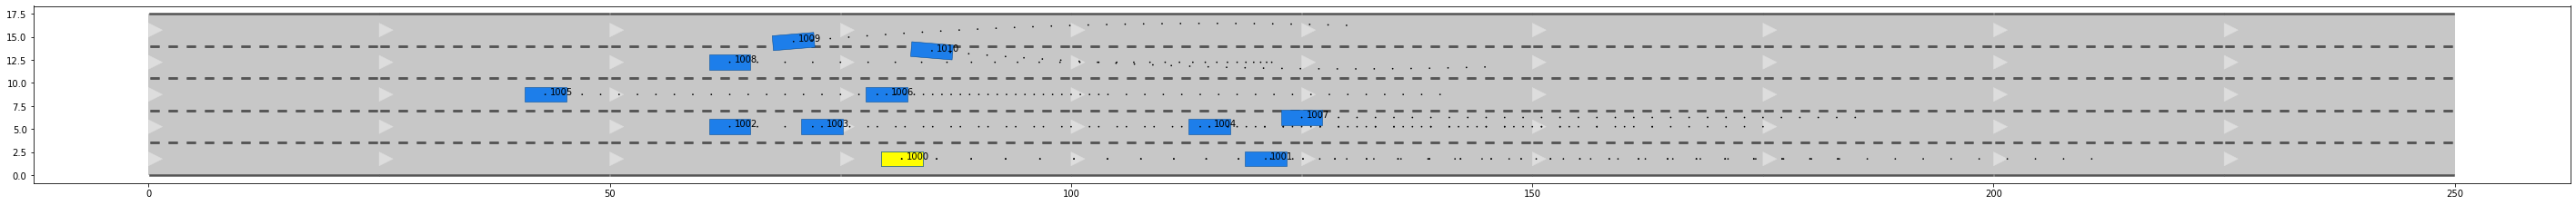

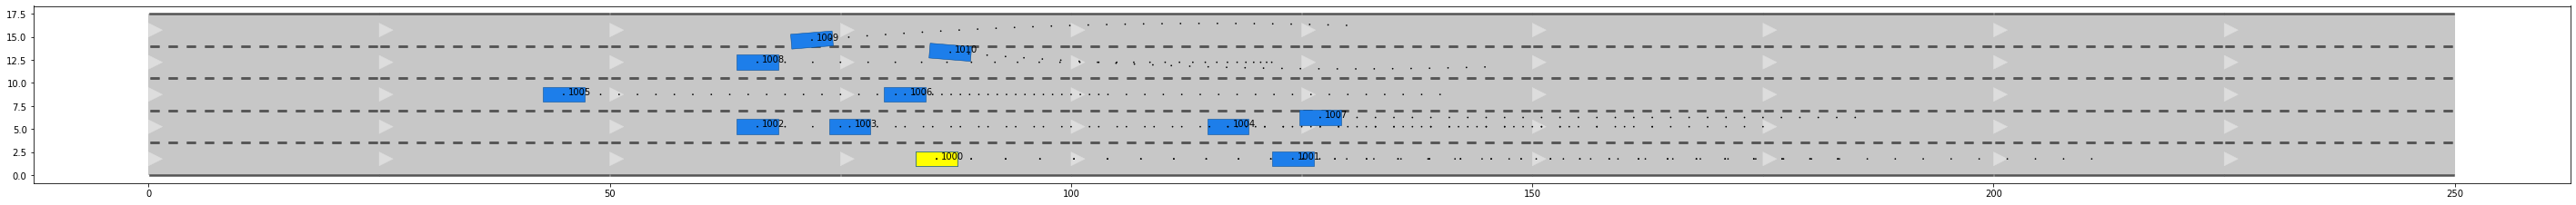

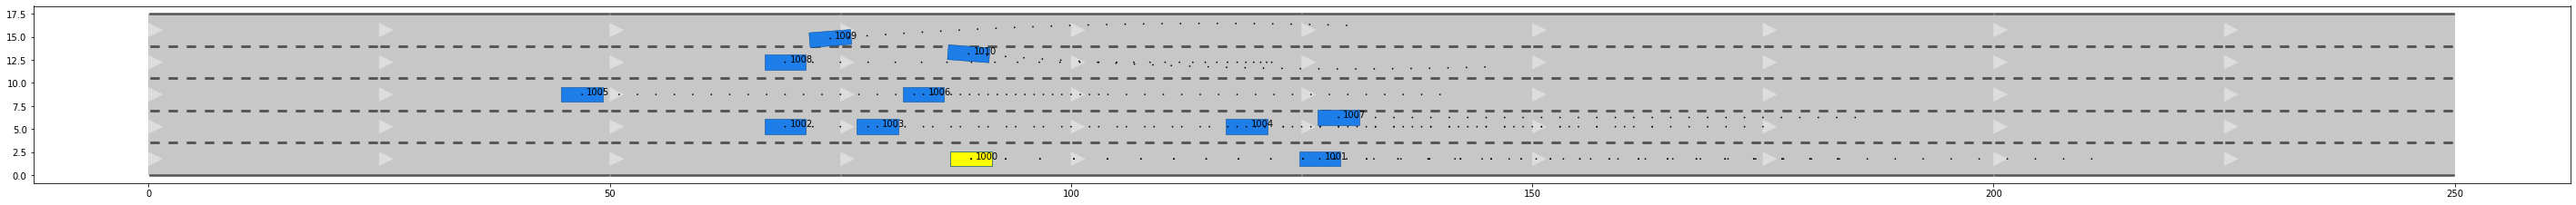

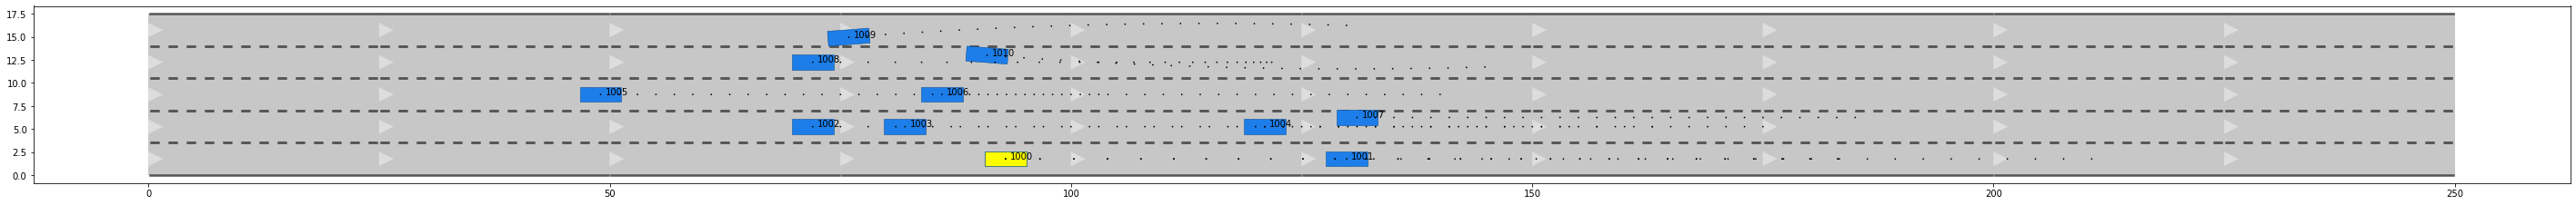

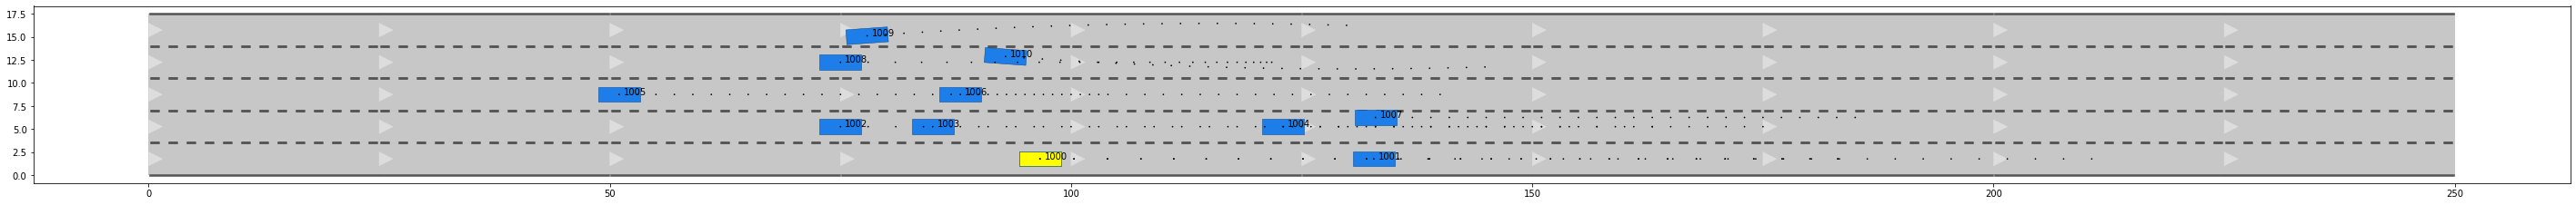

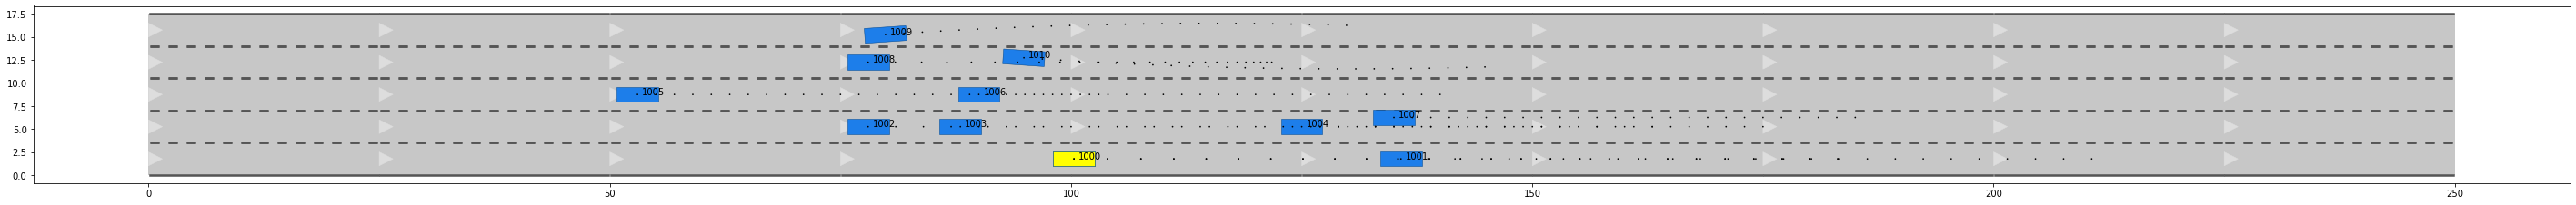

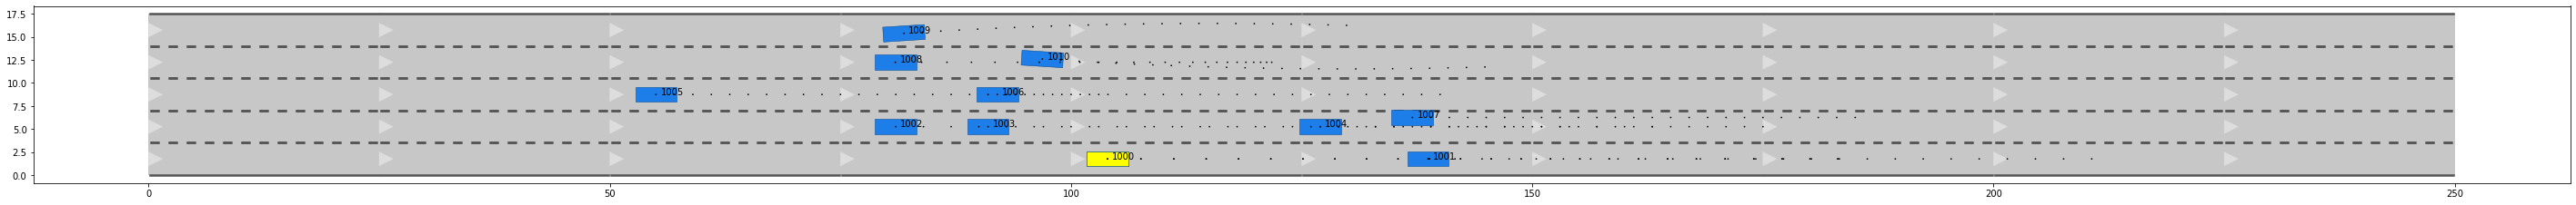

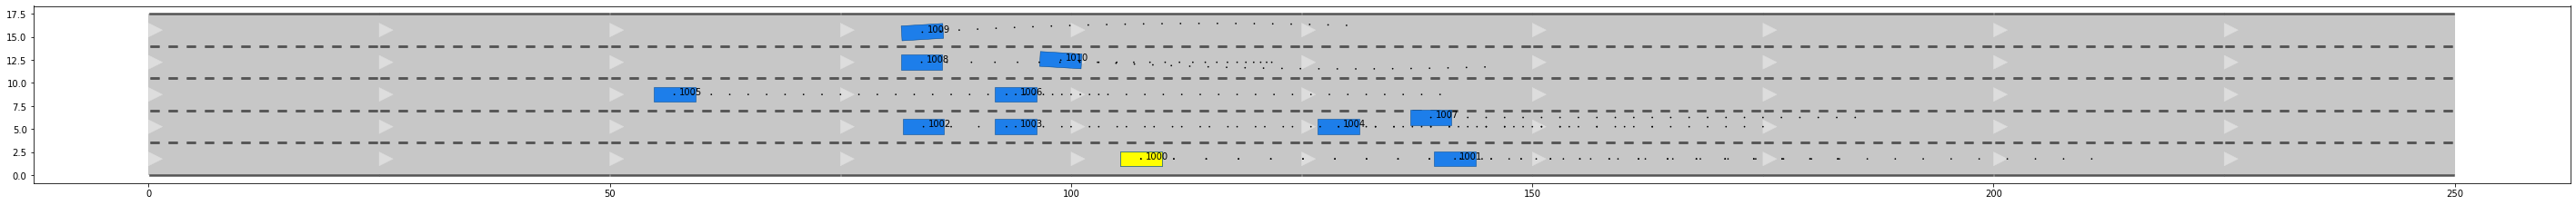

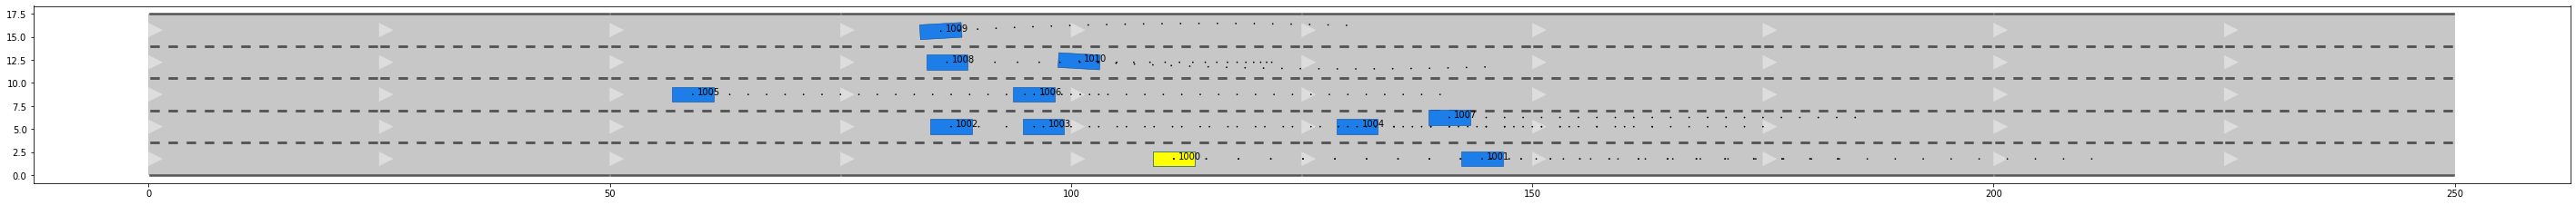

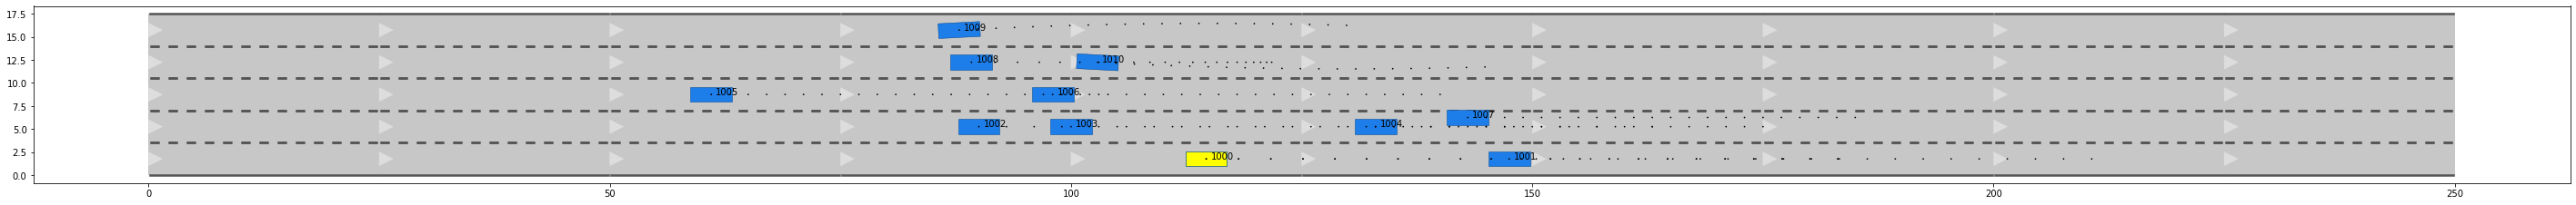

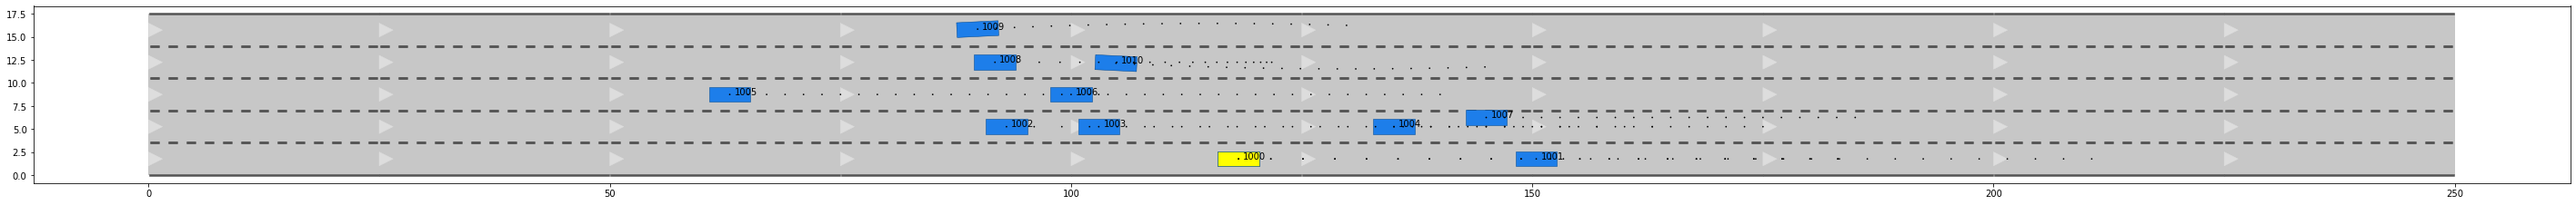

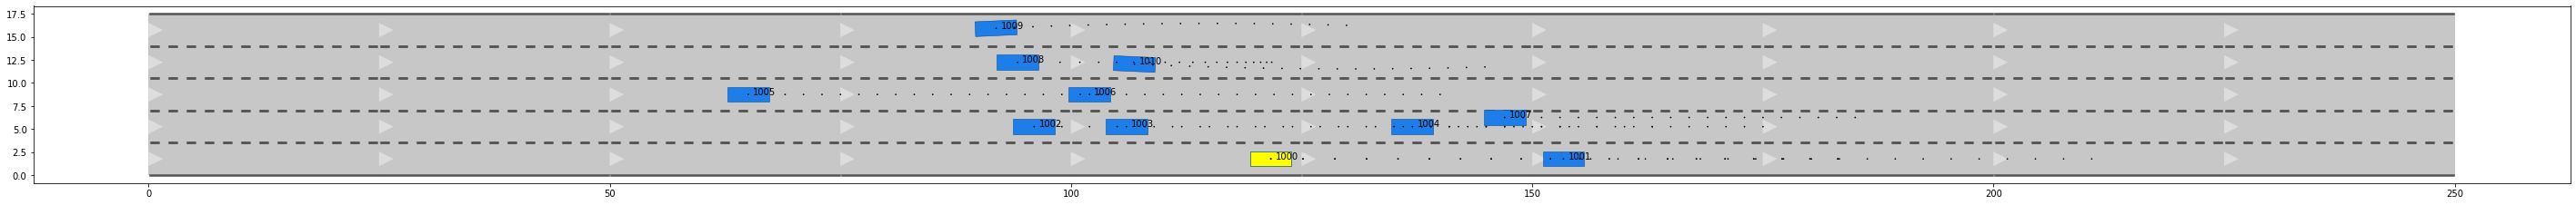

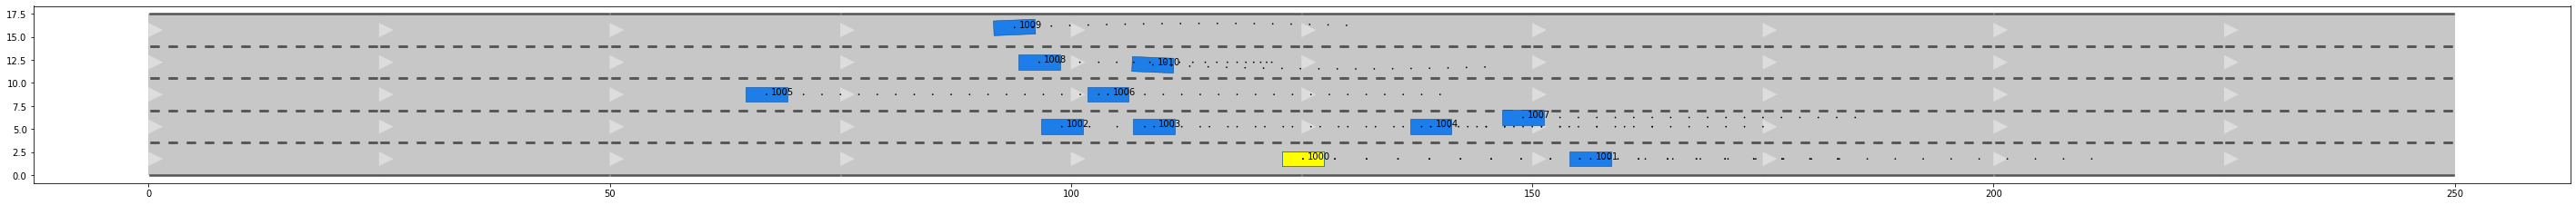

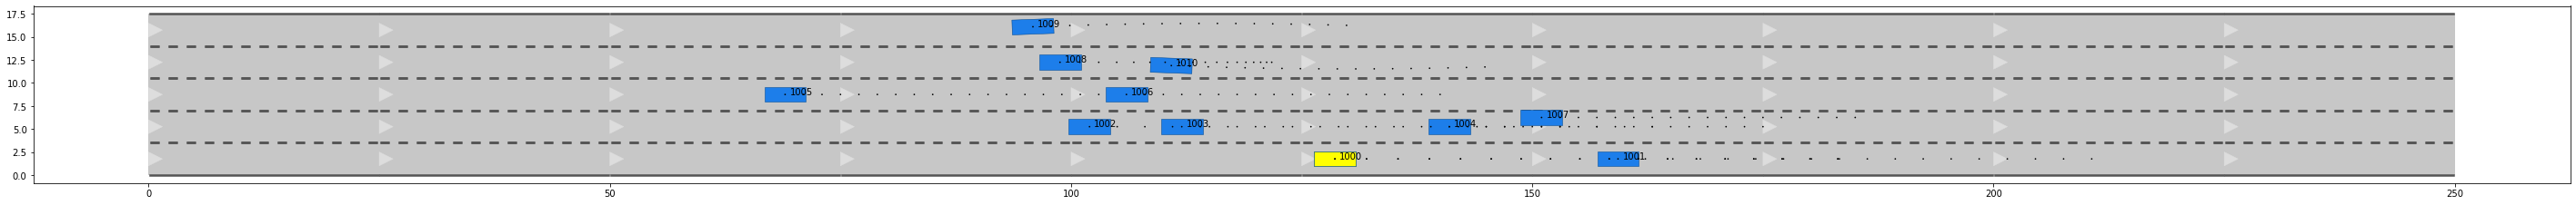

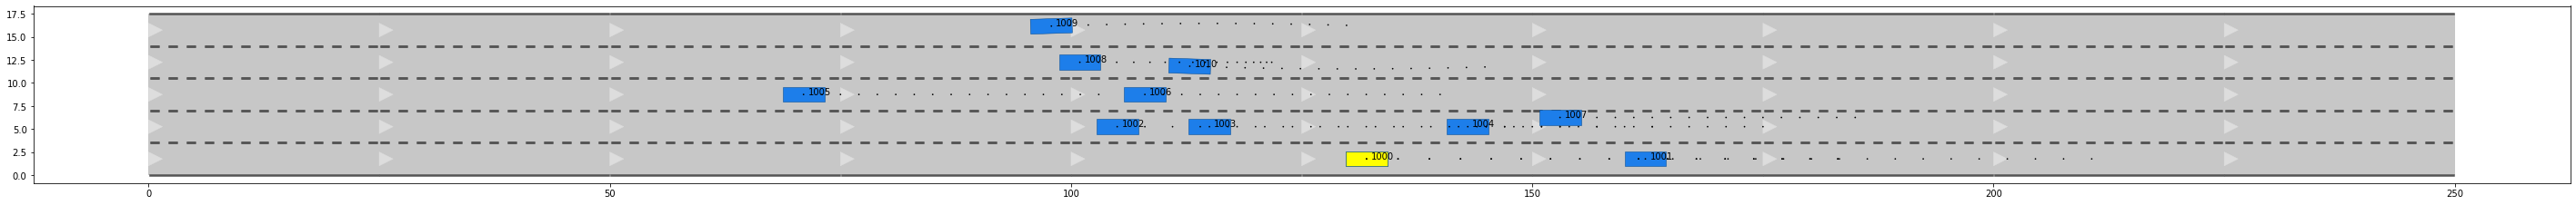

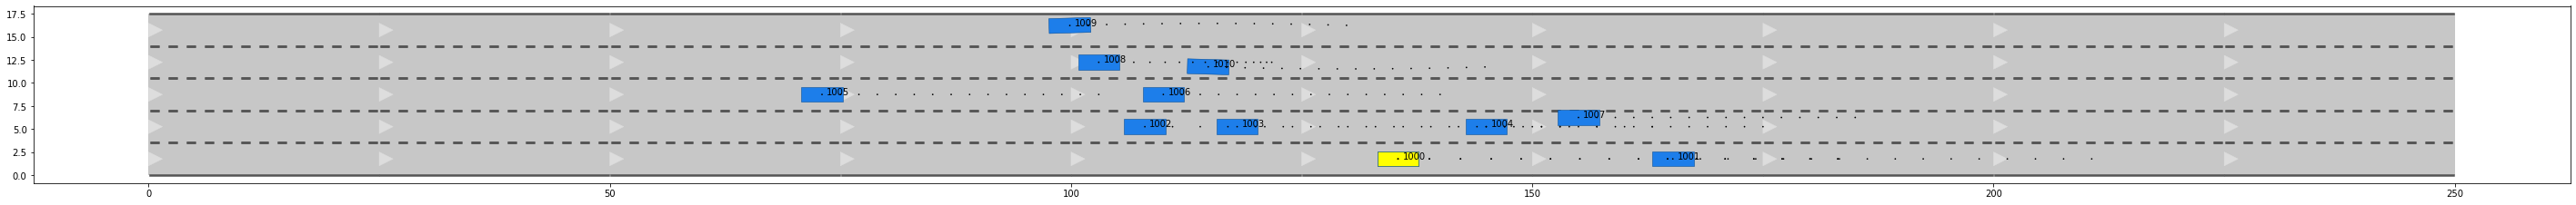

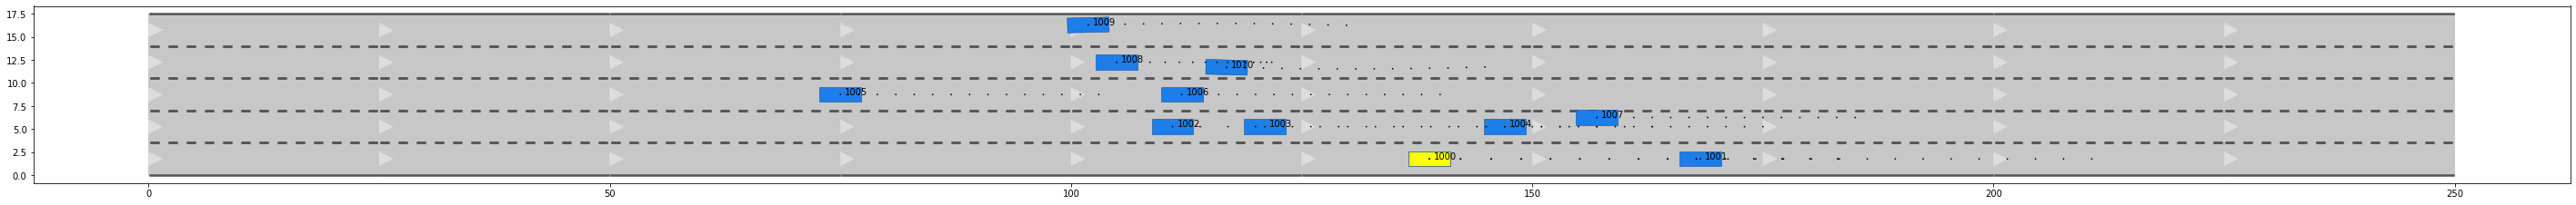

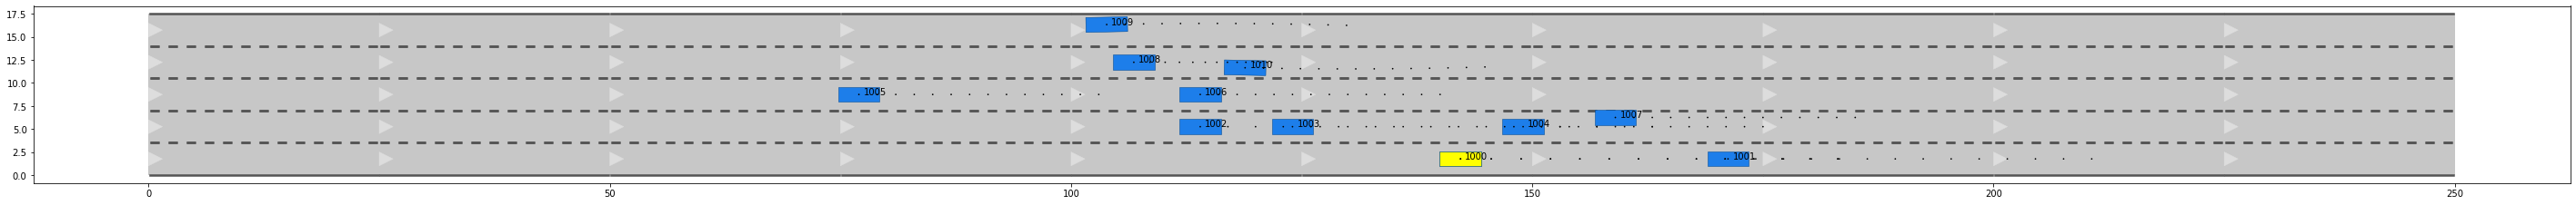

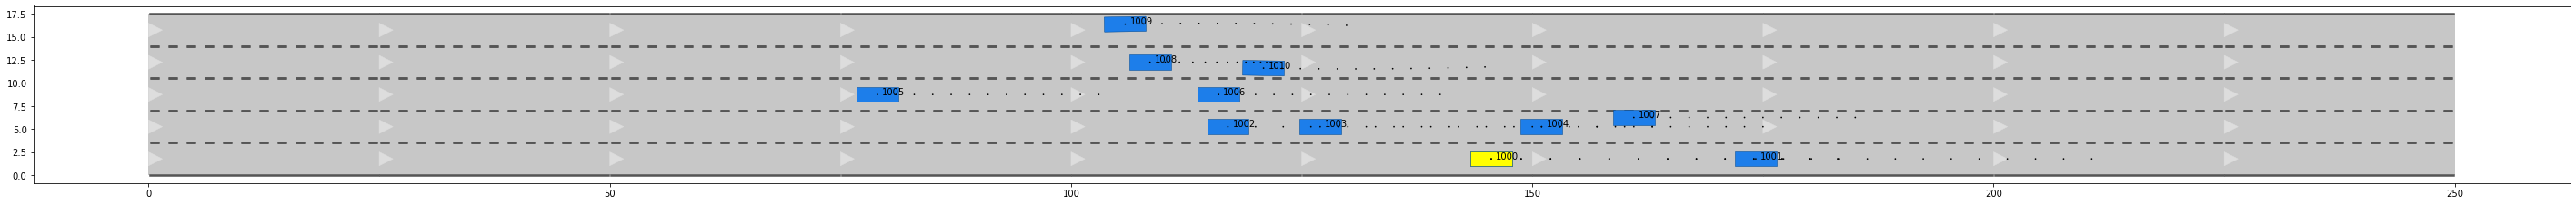

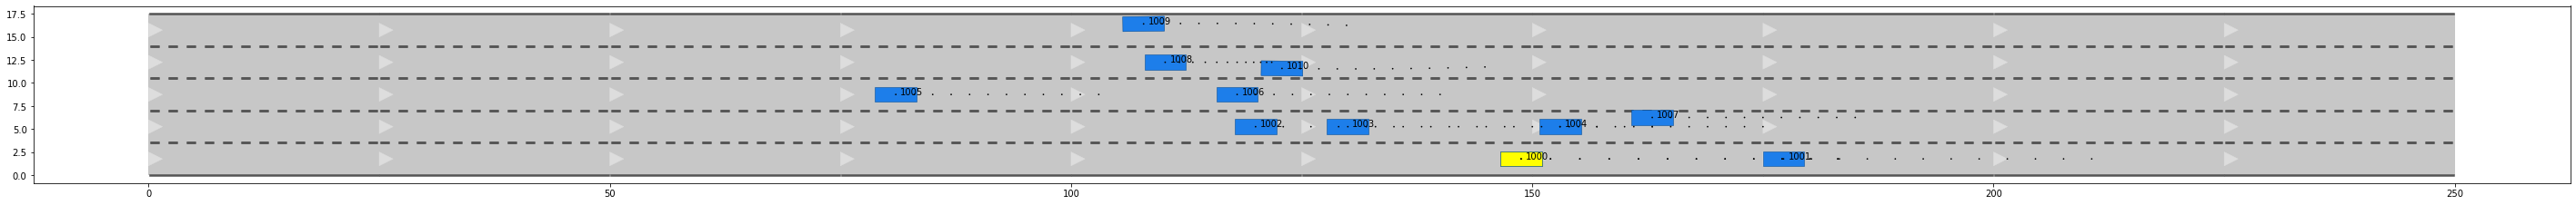

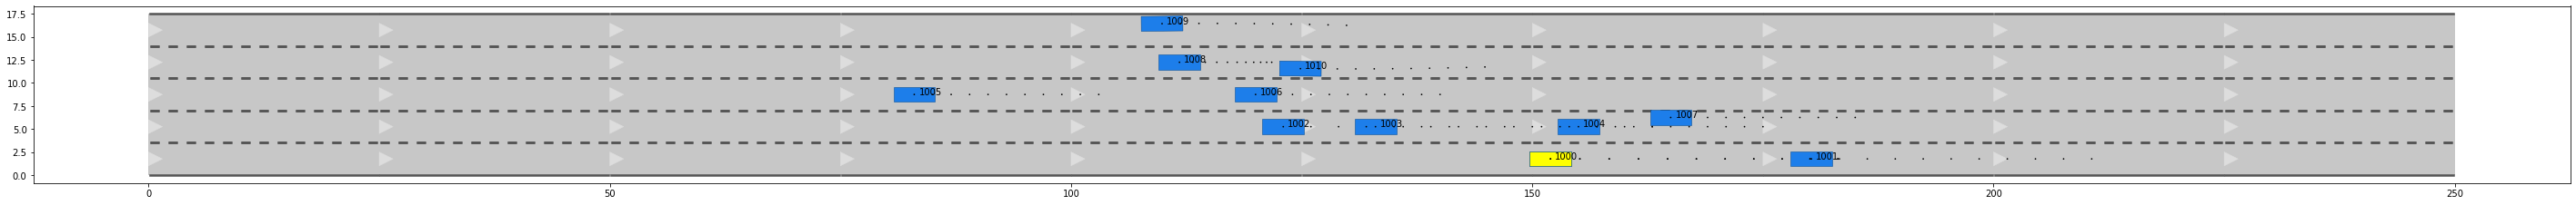

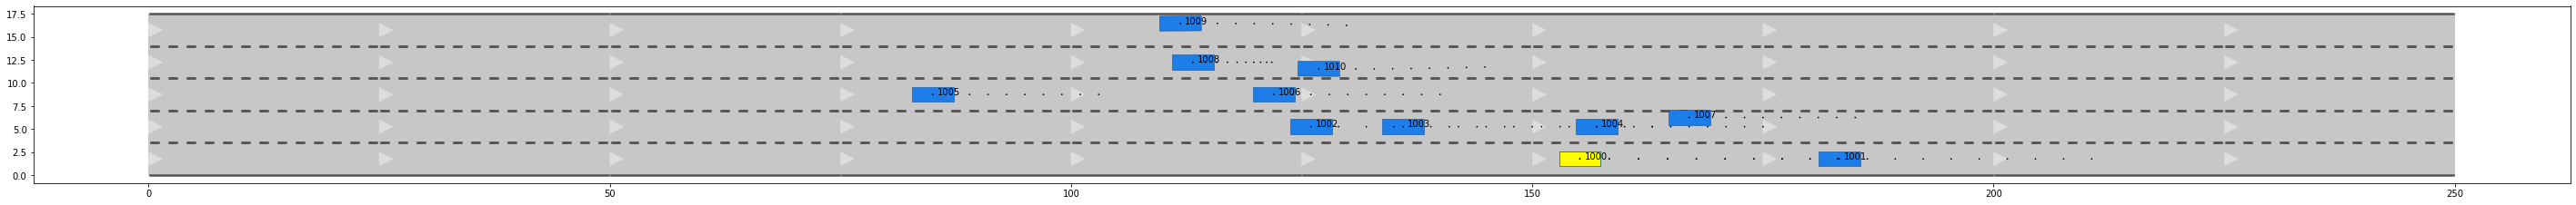

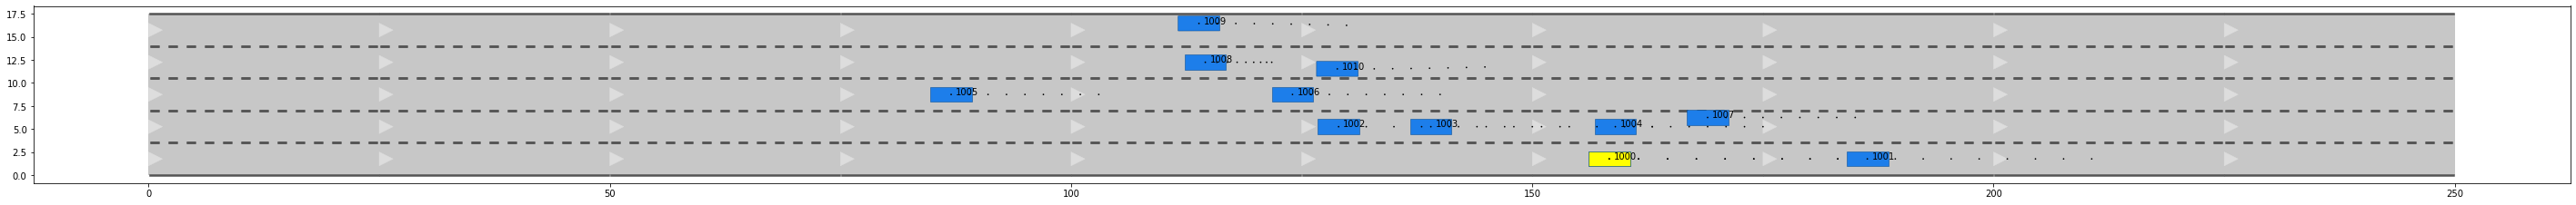

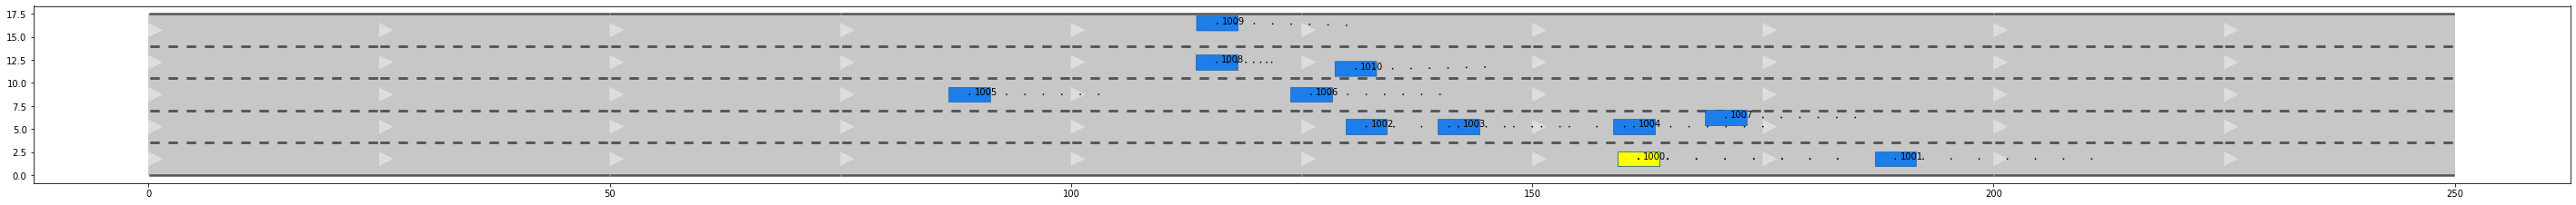

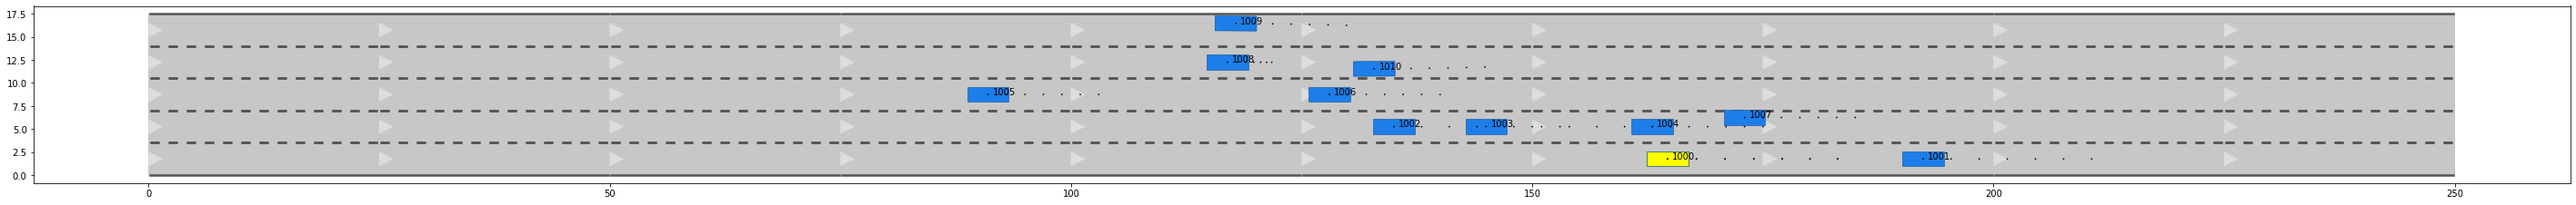

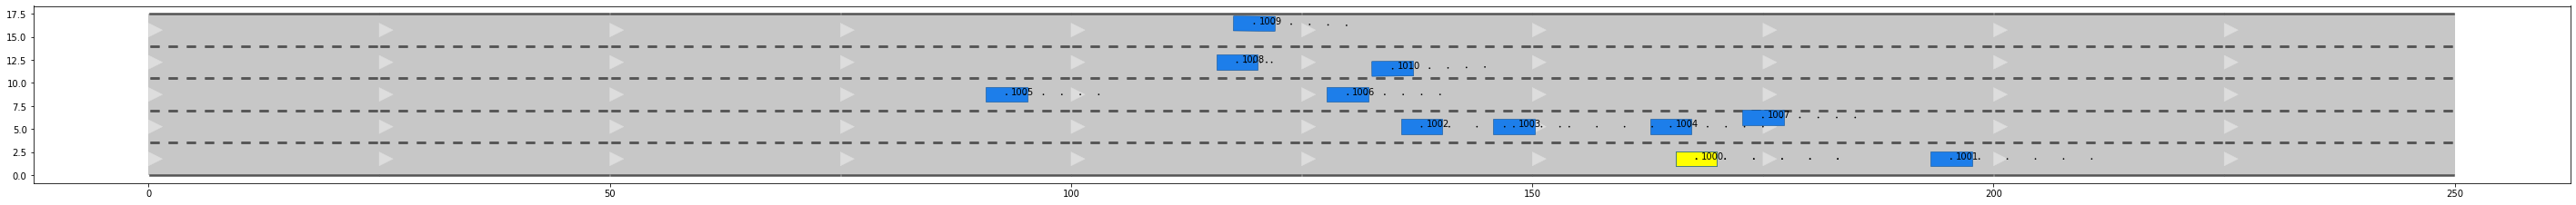

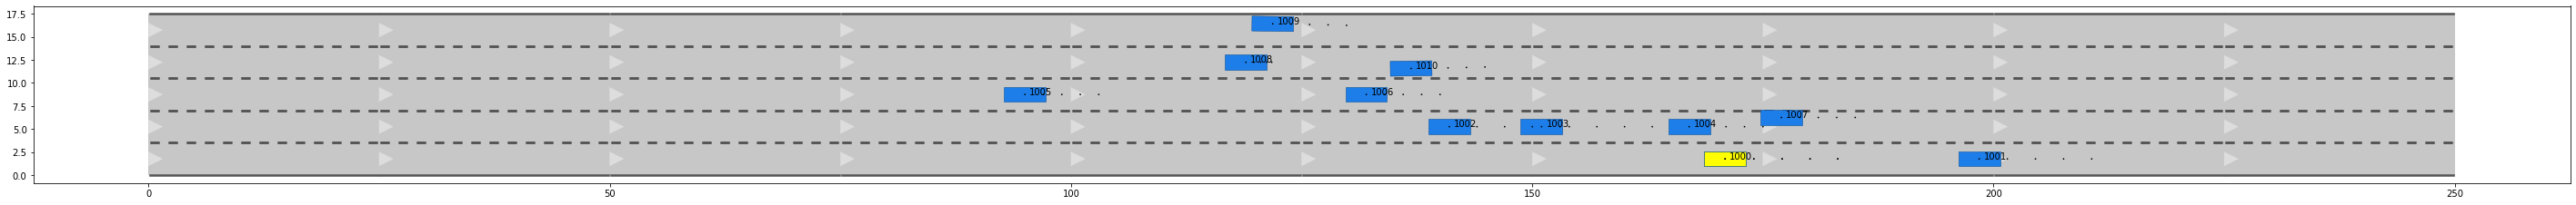

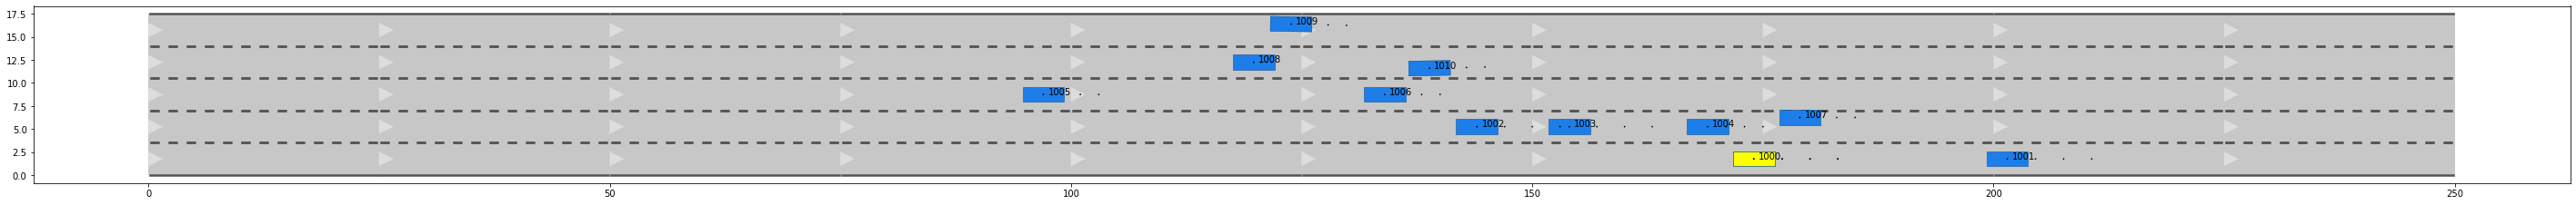

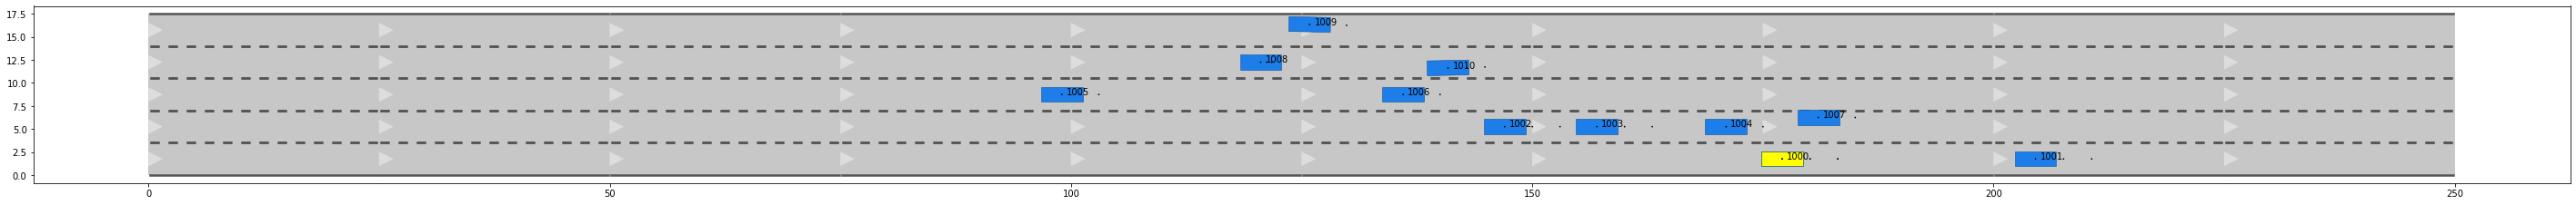

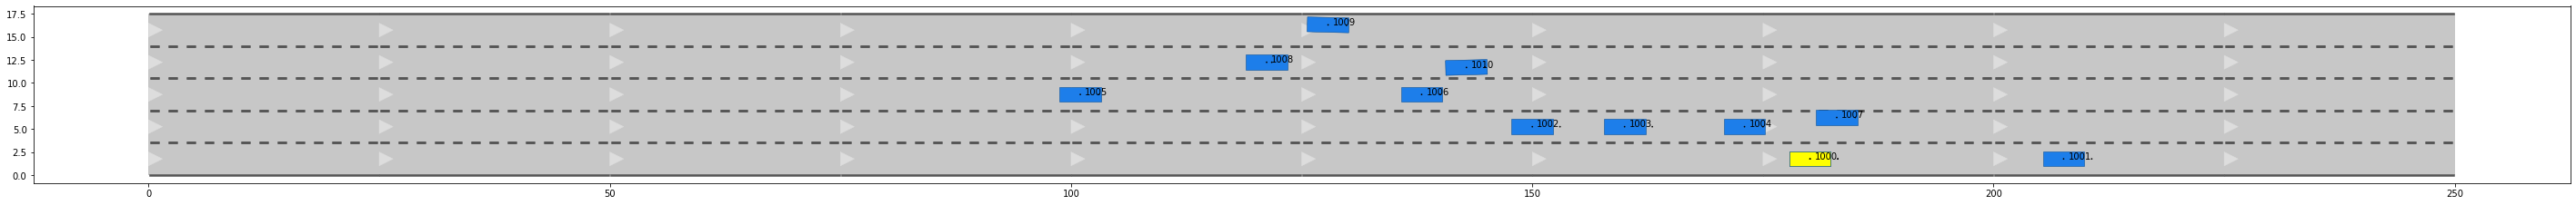

In [4]:
for i in range(0, 50):
    plt.figure(figsize=(50, 20))
    rnd = MPRenderer()
    scenario.draw(rnd, draw_params={'time_begin': i, 'dynamic_obstacle': {'show_label': True}})
    ego_vehicle.draw(rnd, draw_params={'time_begin': i, 'dynamic_obstacle': { 'vehicle_shape': {'occupancy': {'shape': {'rectangle': {'facecolor': 'yellow'}}}}}})
    rnd.render()

## Create rule evaluator

In [9]:
world = World.create_from_scenario(scenario)
world_ego_vehicle = world.vehicle_by_id(ego_vehicle.obstacle_id)
rule_evaluator = RuleEvaluator.create_from_config(world, world_ego_vehicle, rule='R_G1')

## Evaluate rule for each time step & visualize predicates

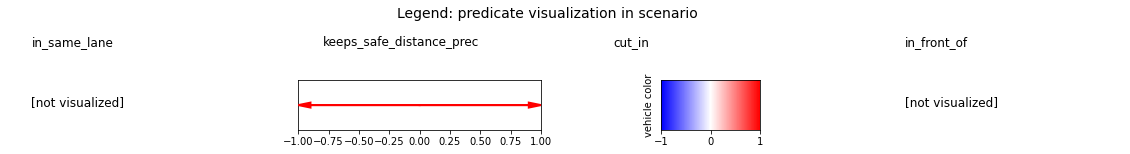

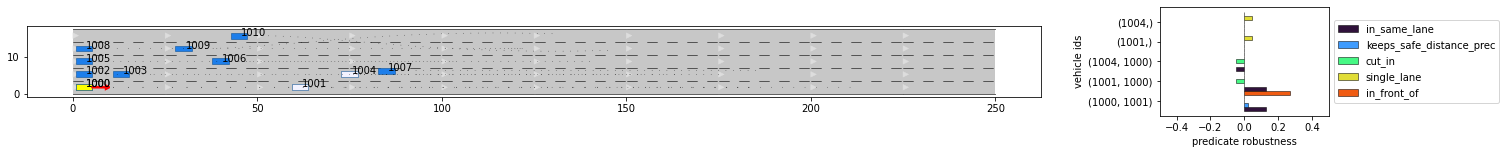

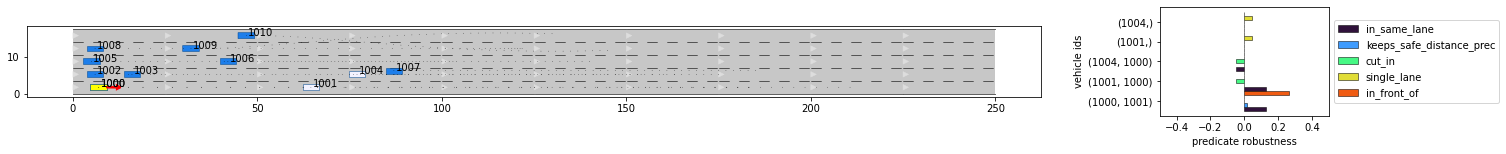

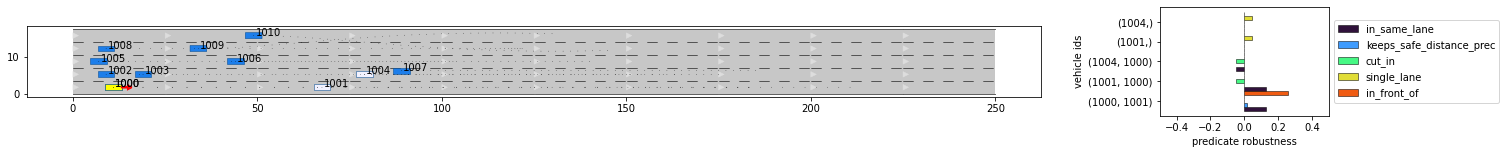

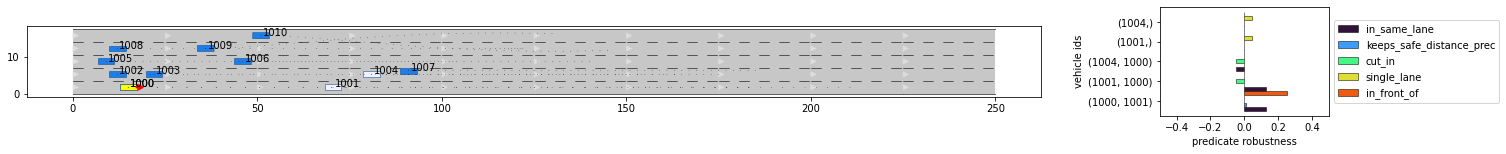

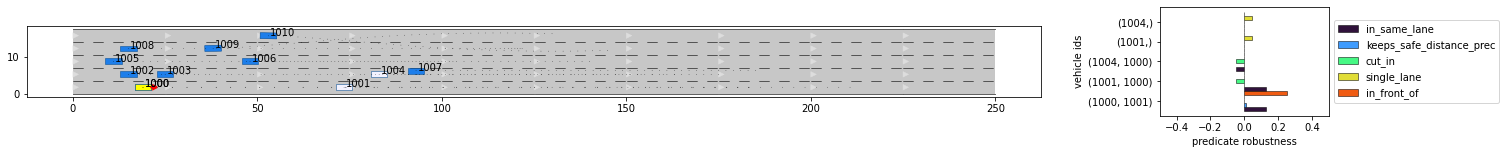

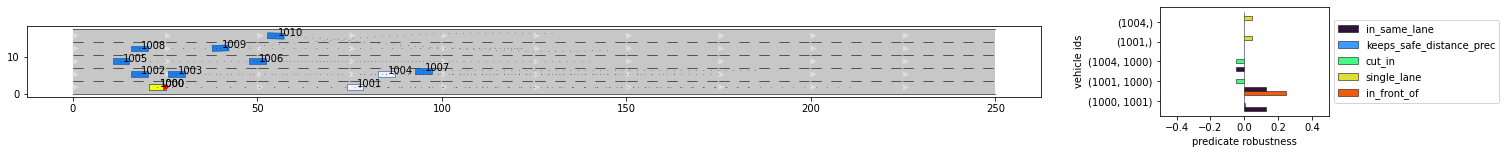

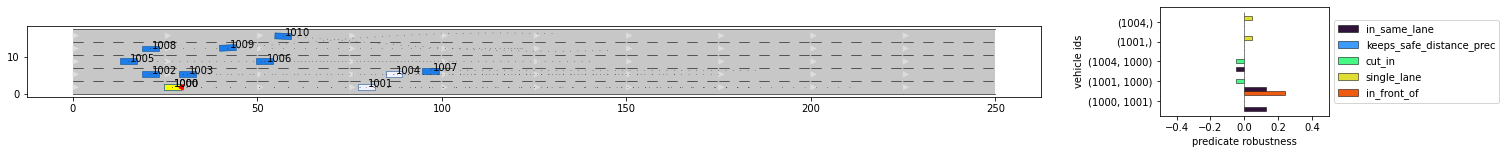

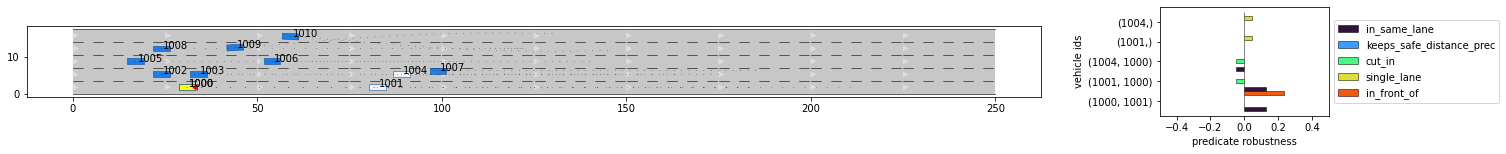

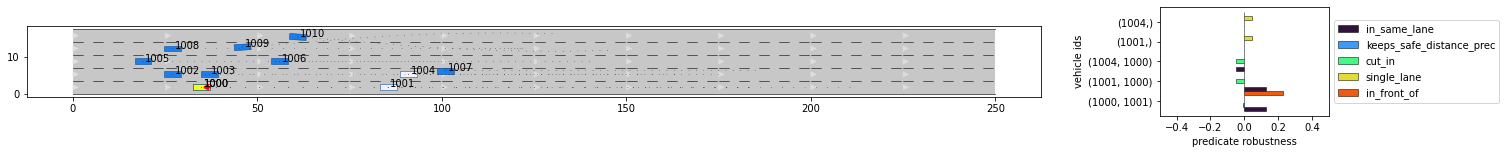

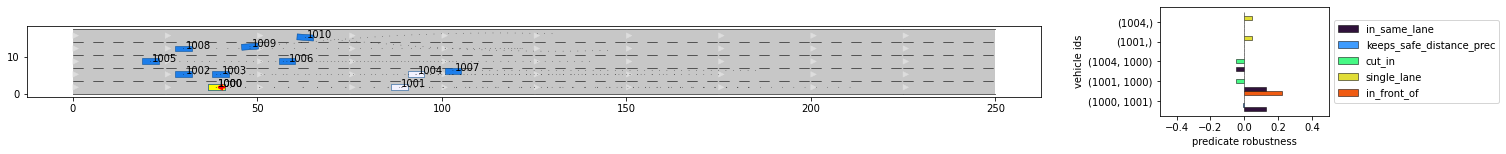

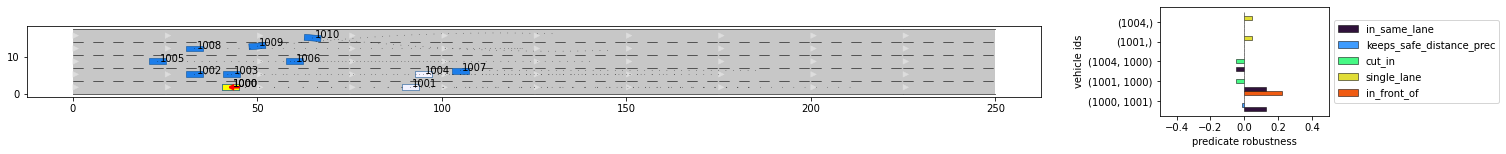

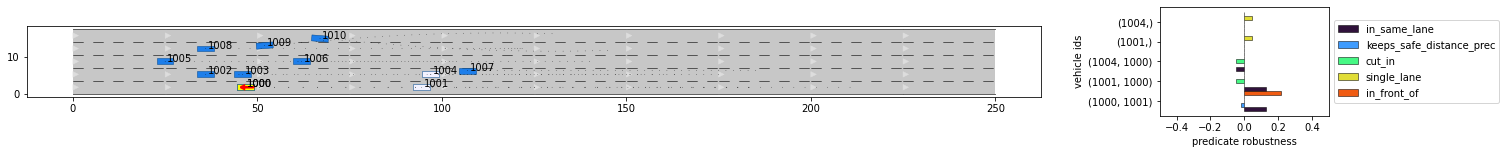

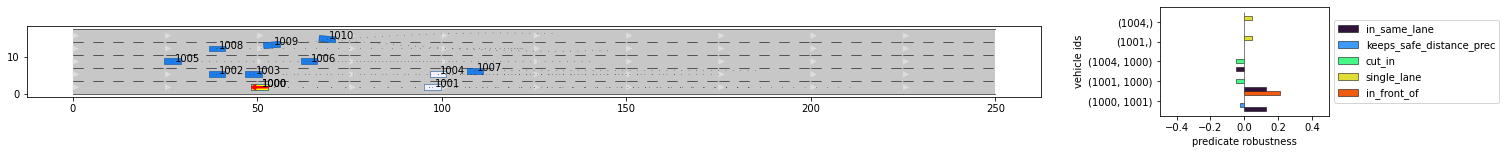

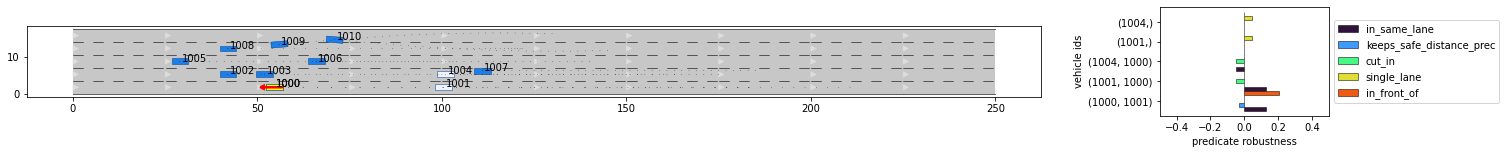

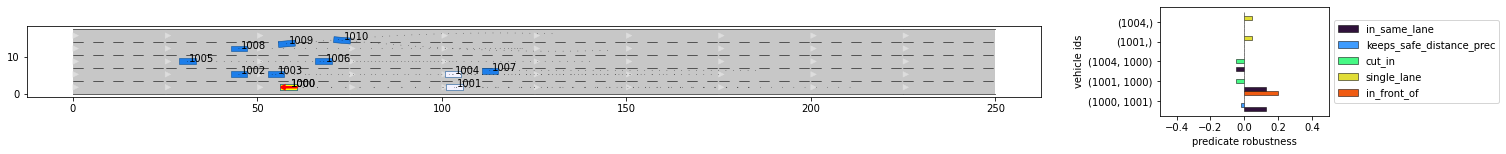

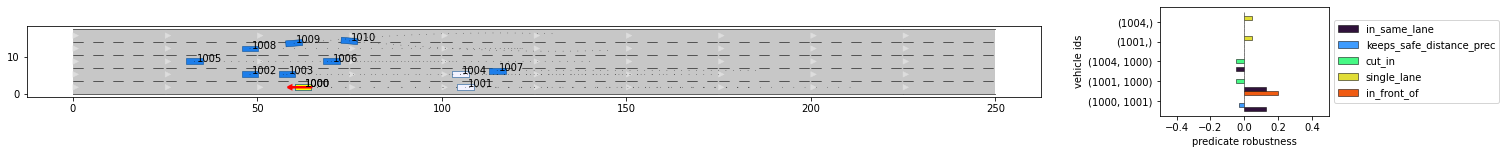

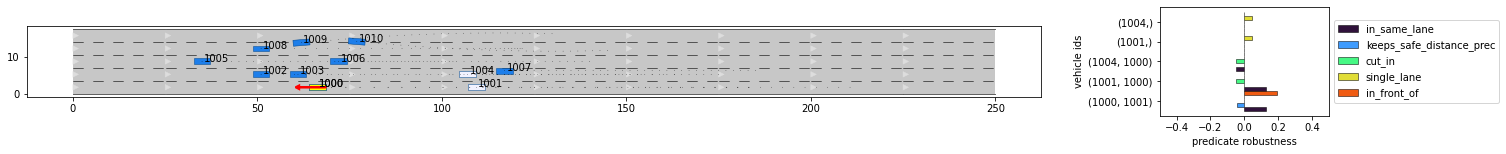

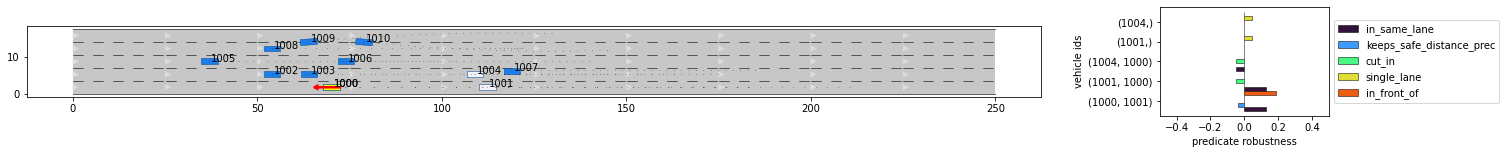

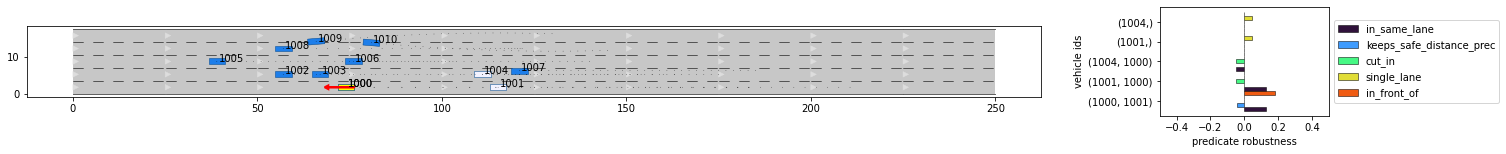

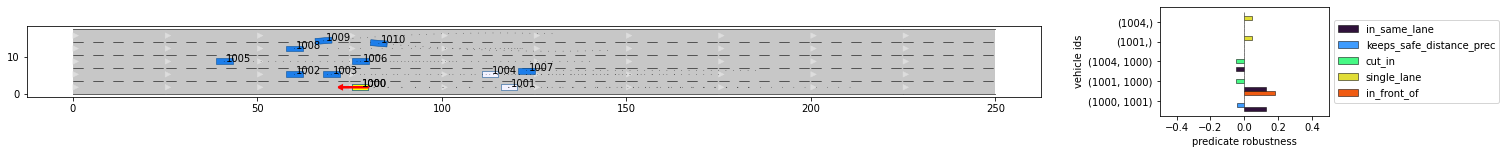

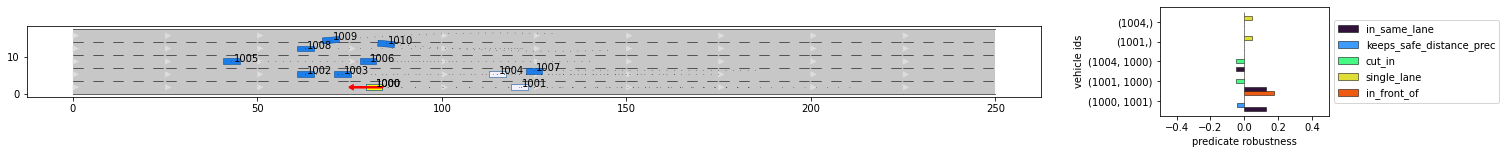

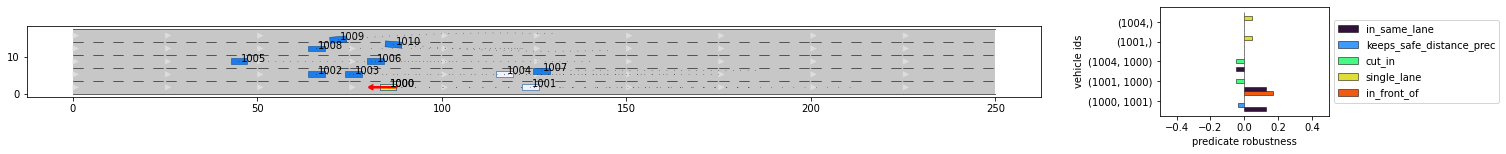

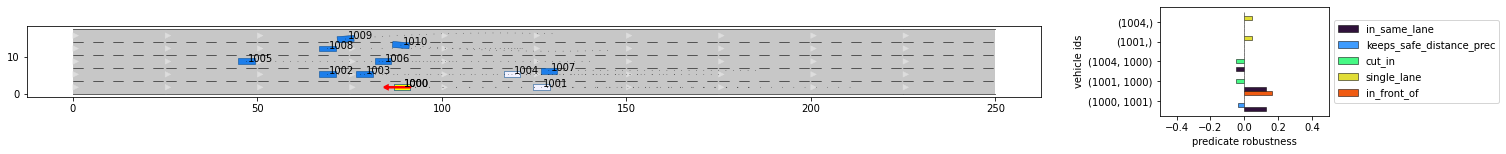

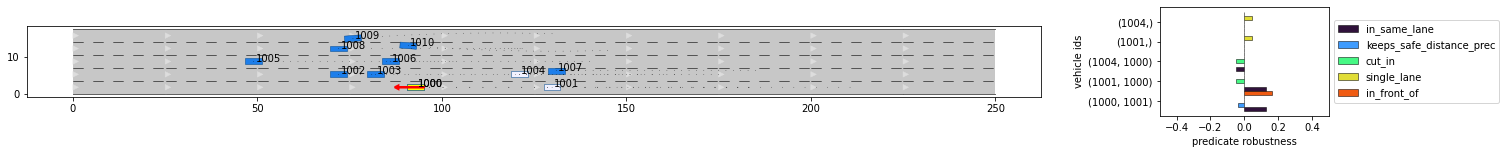

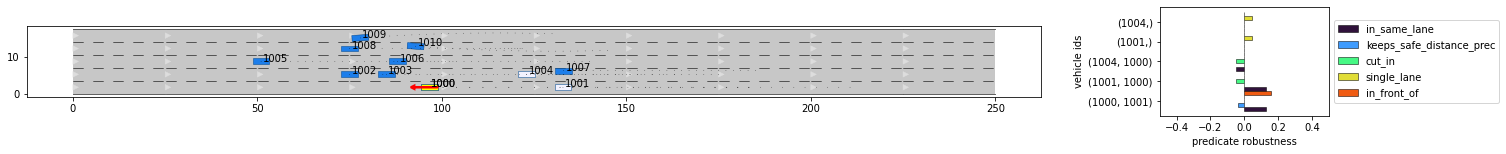

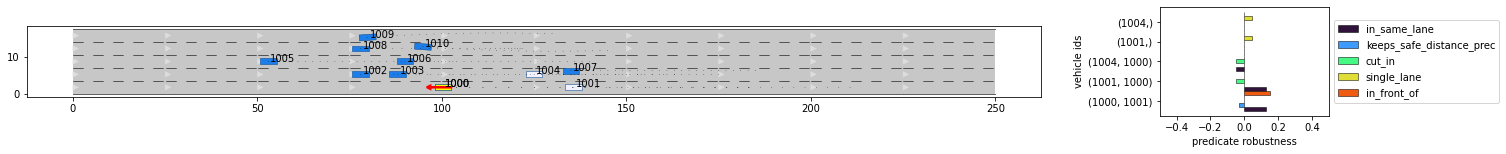

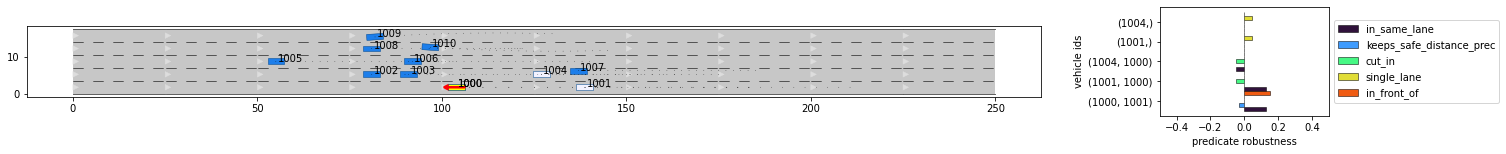

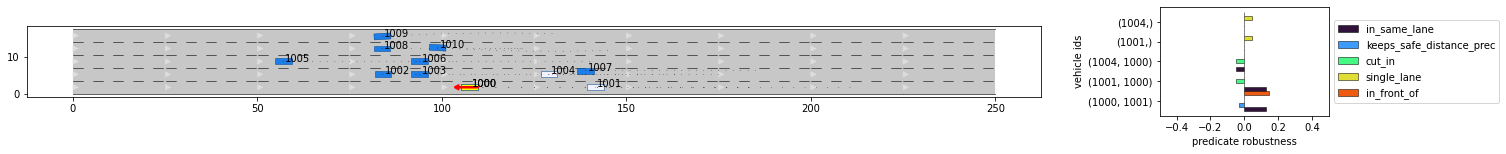

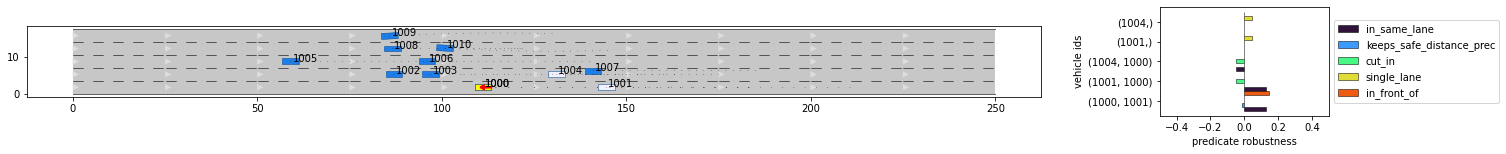

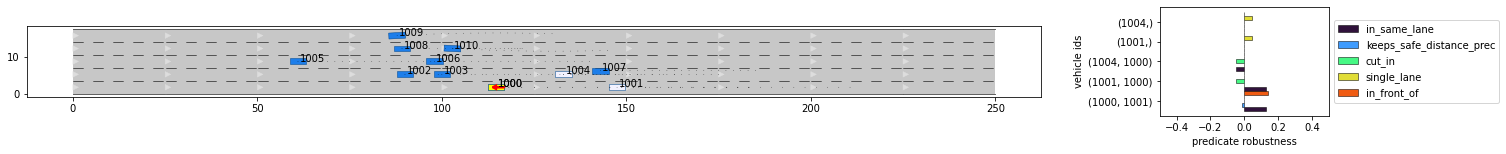

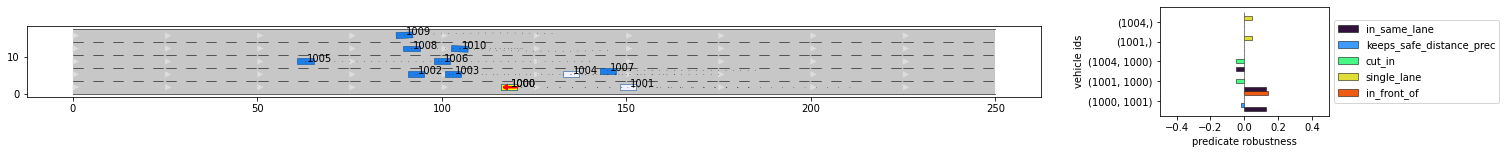

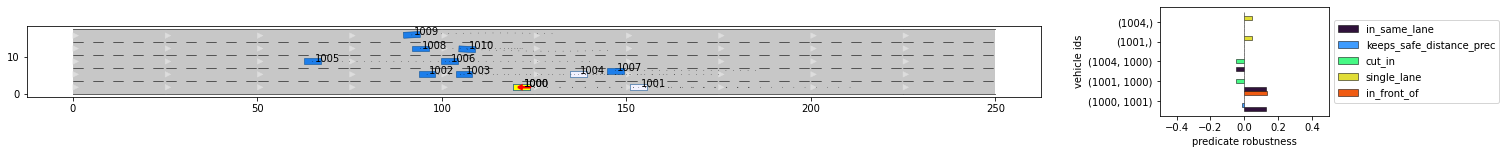

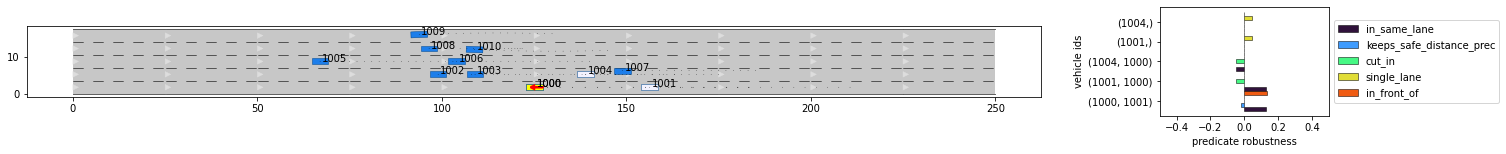

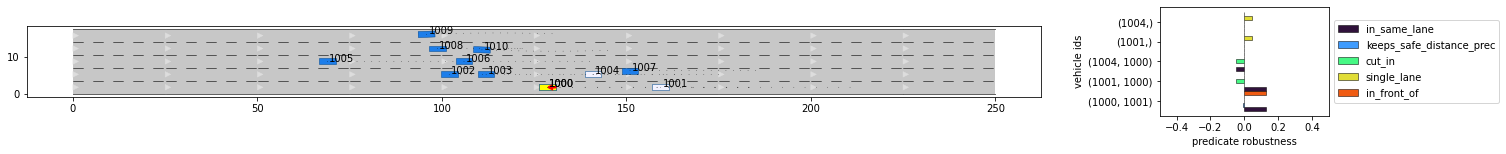

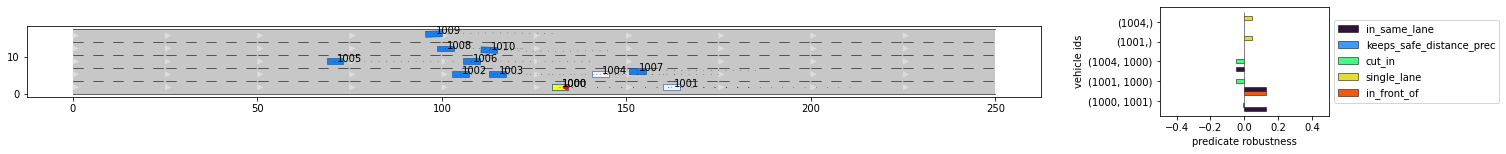

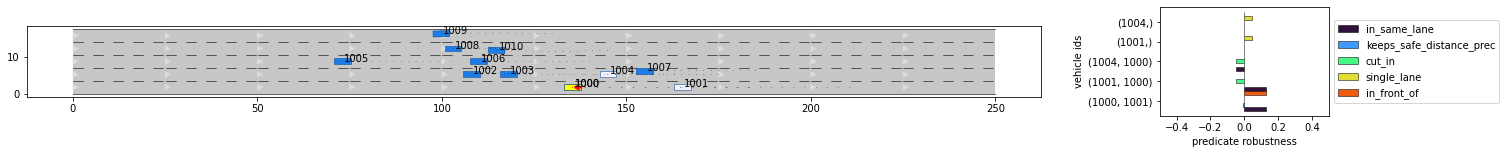

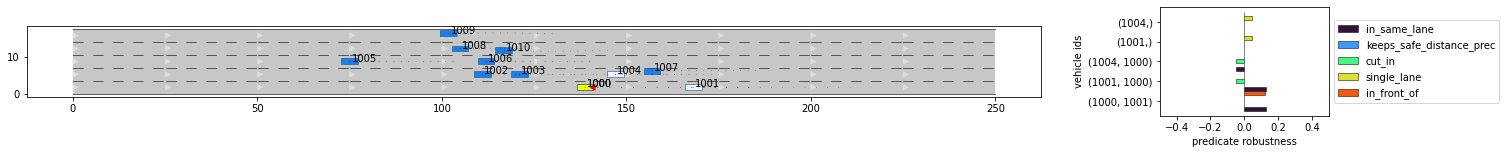

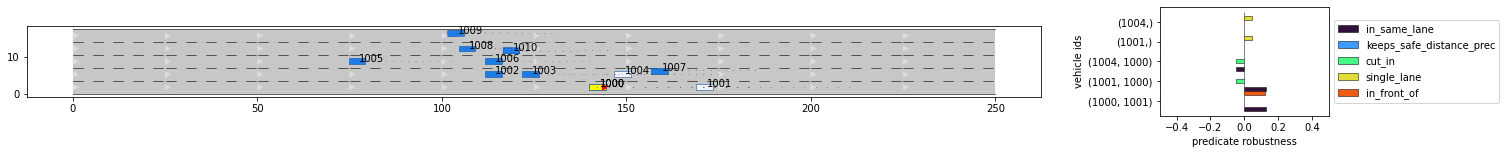

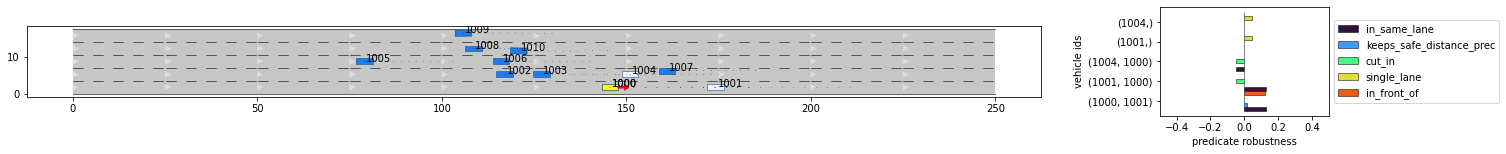

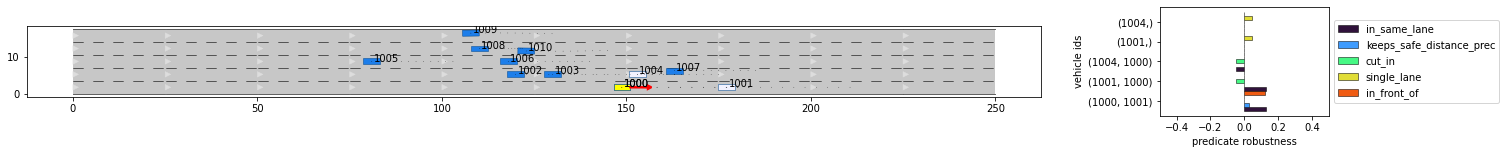

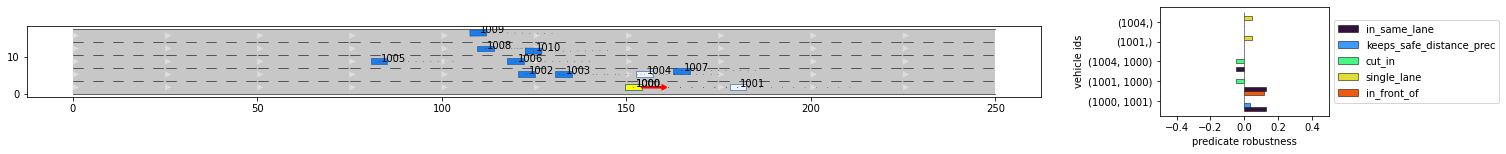

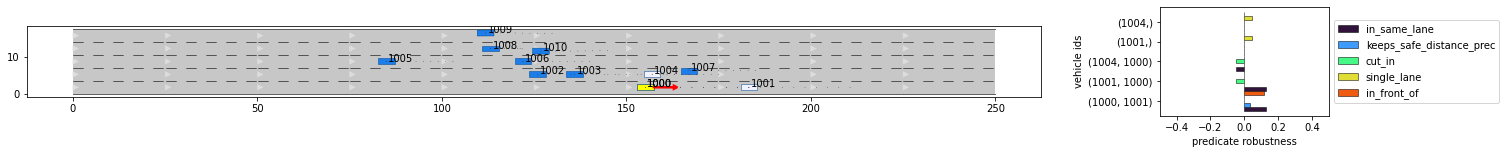

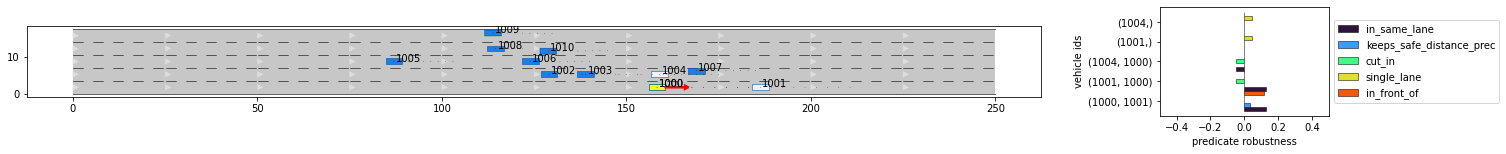

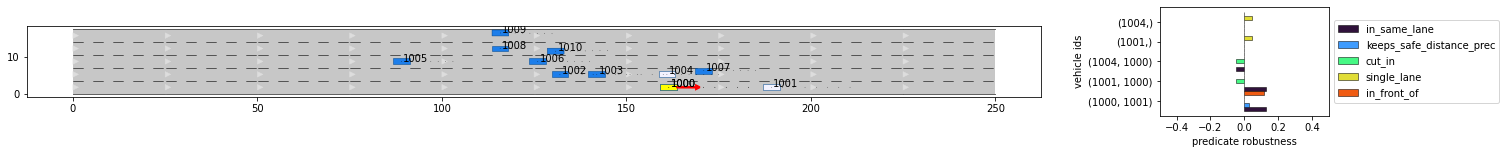

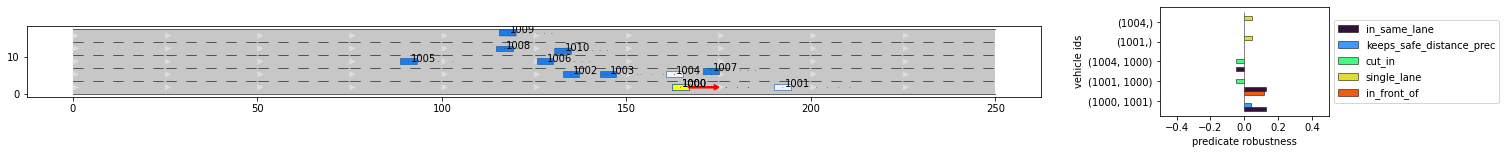

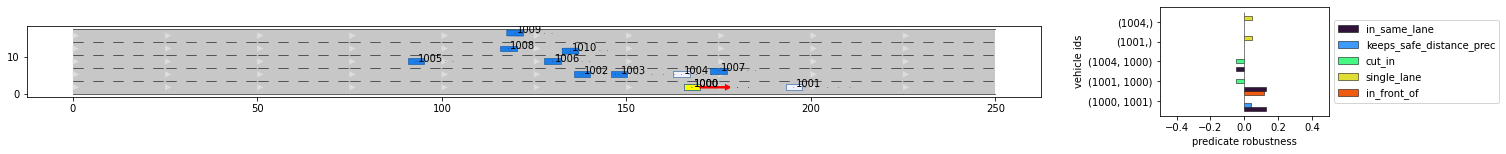

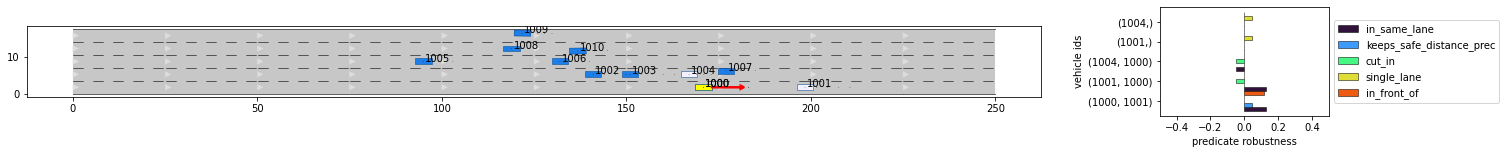

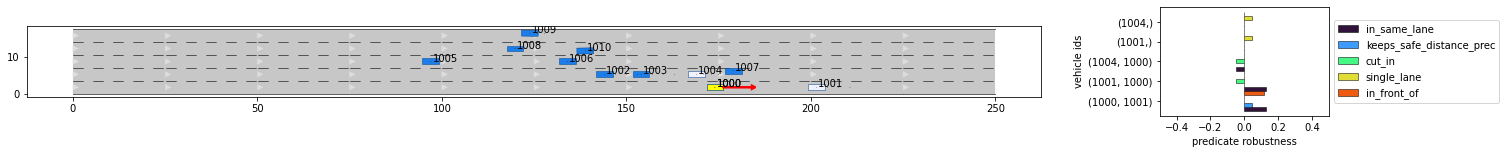

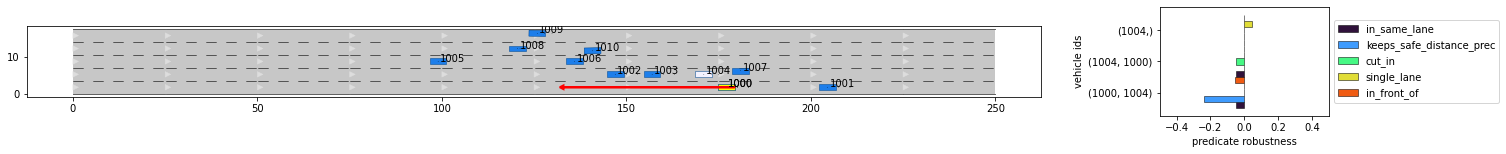

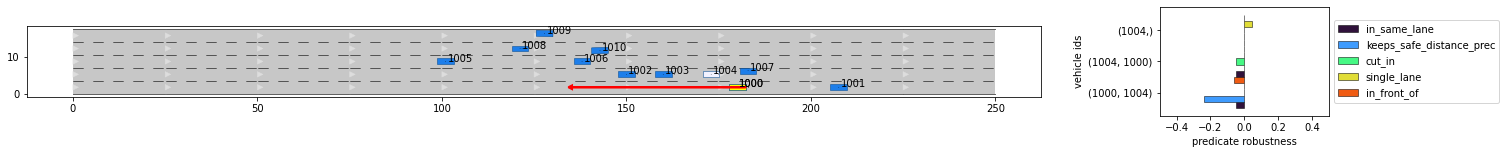

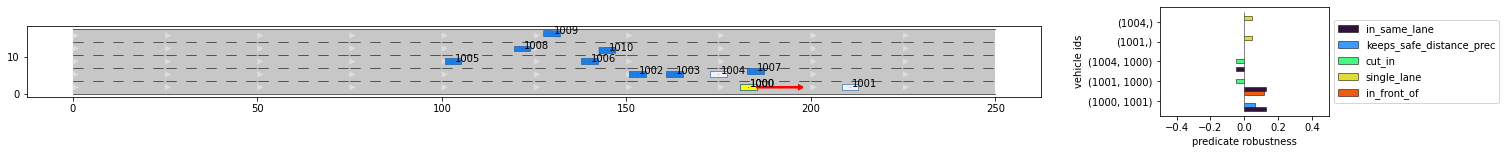

In [10]:
visualization_config = {
    'cut_in': {
        'show_non_effective_predicate_instances_for_vehicles': [(1004, 1000)]
    }
}

current_time_step = 0
while current_time_step < 50:
    robustness = rule_evaluator.update()
    current_time_step = rule_evaluator.current_time

    rule_evaluator.visualize_predicates(visualization_config=visualization_config, plot_scale=1., plot_predicate_bar_chart=True, bar_chart_plot_limits=(-0.5, 0.5))